In [51]:
!pip install transformers torch

# TRANSFORMERS

## Vaswani et al. (2017) - Atention is all you need


O artigo "Attention is All You Need" introduz os Transformers, uma arquitetura inovadora para lidar com problemas sequenciais em aprendizado de máquina. Ele aborda limitações das abordagens baseadas em RNNs e LSTMs e propõe uma solução eficiente: o uso exclusivo do mecanismo de atenção.

**Problema principal abordado:** paralelização de dependências de longa distância.

### Transformers

O Transformer é uma arquitetura de rede neural inovadora proposta no artigo "Attention is All You Need". Ele foi projetado para resolver problemas de aprendizado em sequências, como tradução automática, geração de texto e tarefas relacionadas a linguagem e séries temporais.

#### O que o Transformer trouxe de novo?
* Quebra com as abordagens tradicionais: Antes, modelos como RNNs, LSTMs e GRUs eram as principais escolhas para dados sequenciais. Esses modelos processavam sequências palavra por palavra, de forma serial, o que era lento e limitava o aprendizado de dependências de longo alcance.
* Paralelismo:
O Transformer processa toda a sequência de uma vez, graças ao mecanismo de atenção. Isso torna o treinamento muito mais rápido e escalável.
* Foco no Mecanismo de Atenção: Em vez de depender de recorrência (como RNNs) ou convoluções (como CNNs), o Transformer usa atenção para capturar relações entre tokens.

#### Impacto dessa inovação:
* Melhor desempenho em tarefas de NLP, superando abordagens anteriores.
Base para modelos como BERT, GPT e T5.
* Aplicação além de NLP, como visão computacional (Vision Transformers).

### Self-Attention - Atenção auto-regressiva

 Permite que cada palavra (ou token) de uma sequência "preste atenção" em todas as outras palavras da sequência.

#### Como funciona o Self-Attention?
1. Criação de Vetores (Query, Key, Value):
* Cada token da entrada é transformado em três vetores:
  * Query (Q): Representa "o que essa palavra está buscando".
  * Key (K): Representa "o que essa palavra oferece".
  * Value (V): Representa "a informação associada a essa palavra".
2. Cálculo da Similaridade:
* Para cada par de palavras, calcula-se a similaridade entre o Query de uma palavra e o Key das outras.
3. Distribuição de Atenção:
* Os pesos calculados são normalizados com uma softmax para criar uma distribuição de atenção.
4. Soma Ponderada:
* Os pesos de atenção são usados para combinar os Values, criando uma representação contextual.

In [52]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

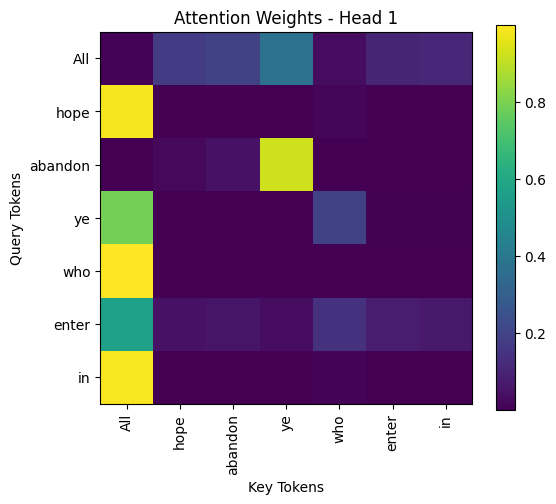

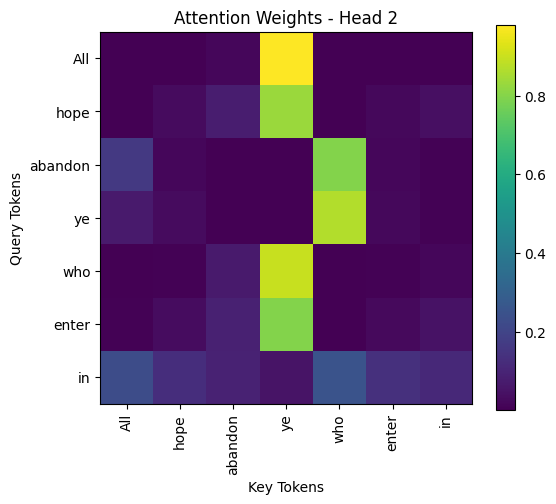

Tokens: ['All', 'hope', 'abandon', 'ye', 'who', 'enter', 'in']

Concatenated Output (Multi-Head Attention):
tensor([[-1.1651,  0.7181,  2.1301, -1.5662],
        [-3.2082,  0.4311,  2.2387, -0.8438],
        [ 2.1234, -1.6151,  1.5250, -0.3737],
        [ 2.1307, -1.5736, -0.8789,  0.5627],
        [-0.7632,  0.3608, -3.6260, -0.6449],
        [-4.1078, -0.8842, -0.7171,  0.4513],
        [-0.7318,  0.3168, -1.3261, -0.2228]])


In [53]:
# Simplificado: sequência e embeddings menores
tokens = ["All", "hope", "abandon", "ye", "who", "enter", "in"]
sequence_length = len(tokens)
embed_size = 4  # Dimensão reduzida para eficiência
num_heads = 2

# Embeddings simulados
embeddings = torch.randn(sequence_length, embed_size)

# Pesos para multi-head attention (2 cabeças)
W_q = torch.randn(num_heads, embed_size, embed_size // num_heads)
W_k = torch.randn(num_heads, embed_size, embed_size // num_heads)
W_v = torch.randn(num_heads, embed_size, embed_size // num_heads)

# Calculando Q, K, V para cada cabeça
Q = torch.einsum("ij,hjk->hik", embeddings, W_q)
K = torch.einsum("ij,hjk->hik", embeddings, W_k)
V = torch.einsum("ij,hjk->hik", embeddings, W_v)

# Atenção escalada para cada cabeça
scores = torch.einsum("hik,hjk->hij", Q, K)
scaled_scores = scores / torch.sqrt(torch.tensor(embed_size // num_heads, dtype=torch.float32))
attention_weights = F.softmax(scaled_scores, dim=-1)

# Aplicação de atenção nos valores
outputs = torch.einsum("hij,hjk->hik", attention_weights, V)
concatenated_output = outputs.view(sequence_length, -1)  # Concatenar saídas de todas as cabeças

# Visualizando os pesos de atenção para cada cabeça
for head in range(num_heads):
    plt.figure(figsize=(6, 5))
    plt.imshow(attention_weights[head].detach().numpy(), cmap="viridis")
    plt.title(f"Attention Weights - Head {head + 1}")
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.xticks(range(sequence_length), tokens, rotation=90)
    plt.yticks(range(sequence_length), tokens)
    plt.colorbar()
    plt.show()

# Exibir o resultado concatenado
print("Tokens:", tokens)
print("\nConcatenated Output (Multi-Head Attention):")
print(concatenated_output)


### Abandono de RNNs e CNNs

#### Limitações de RNNs

Recorrência (RNNs/LSTMs):
* Os modelos processavam sequências de forma serial, palavra por palavra, acumulando informações ao longo do tempo.
* Problema: Ineficiência (dificuldade em paralelizar o treinamento) e dificuldade em capturar dependências de longo alcance.

#### Limitações de CNNsConvolução (CNNs):

* As CNNs processam a entrada em blocos de palavras vizinhas (janelas locais).
* Problema: Embora eficientes, elas capturam relações locais e têm dificuldade em lidar com dependências distantes sem várias camadas.

#### Forma de operação dos Transformers

1. Eliminação de recorrência:
* O Transformer processa toda a sequência de uma vez, sem depender de uma ordem serial.
* Isso melhora a paralelização e reduz o tempo de treinamento.
2. Dispensa convoluções:
* Em vez de usar janelas locais, o mecanismo de atenção examina toda a sequência de entrada diretamente, capturando relações globais.
3. Eficiência Computacional:
* A ausência de recorrência permite que o Transformer use GPUs e TPUs de maneira mais eficiente.
4. Melhor aprendizado:
* Dependências de longo alcance são aprendidas mais facilmente, já que o modelo analisa a sequência como um todo.

In [54]:
from transformers import DistilBertTokenizer, DistilBertForQuestionAnswering, AutoTokenizer
import torch
import torch.nn as nn
import time

In [55]:
# Configurações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sequence_length = 512

# Texto longo (Contexto)
context = """
THROUGH me the way is to the city dolent;
Through me the way is to eternal dole;
Through me the way among the people lost.
Justice incited my sublime Creator;
Created me divine Omnipotence,
The highest Wisdom and the primal Love.
Before me there were no created things,
Only eterne, and I eternal last.
“All hope abandon, ye who enter in!”
These words in sombre colour I beheld
Written upon the summit of a gate;
Whence I: “Their sense is, Master, hard to me!”
And he to me, as one experienced:
“Here all suspicion needs must be abandoned,
All cowardice must needs be here extinct.
We to the place have come, where I have told thee
Thou shalt behold the people dolorous
Who have foregone the good of intellect.”
And after he had laid his hand on mine
With joyful mien, whence I was comforted,
He led me in among the secret things.
"""

In [56]:
# Pergunta
question = "What words were written upon a gate?"

In [57]:
# Tokenizador compartilhado com o experimento de QA
qa_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
)

In [58]:
# Garante que sequence_length exista
try:
    sequence_length
except NameError:
    sequence_length = 128

# Tokenização do contexto e da pergunta
# Correção principal: usar qa_tokenizer(...) em vez de qa_tokenizer.encode_plus(...)
qa_inputs = qa_tokenizer(
    question,
    context,
    return_tensors="pt",
    max_length=sequence_length,
    truncation=True,
    padding="max_length"
)

inputs_ids = qa_inputs["input_ids"].to(device)
input_ids = inputs_ids  # alias para manter compatibilidade com código anterior
attention_mask = qa_inputs["attention_mask"].to(device)

class SimpleLSTMForQA(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size):
        super(SimpleLSTMForQA, self).__init__()
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc_start = nn.Linear(hidden_size, 1)
        self.fc_end = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        start_logits = self.fc_start(lstm_out).squeeze(-1)
        end_logits = self.fc_end(lstm_out).squeeze(-1)
        return start_logits, end_logits

hidden_size = 768
vocab_size = qa_tokenizer.vocab_size

lstm_model = SimpleLSTMForQA(
    vocab_size,
    hidden_size,
    hidden_size
).to(device)

# Responder à pergunta com LSTM
# Observação: este LSTM está inicializado aleatoriamente; ele roda como experimento comparativo,
# mas não deve ser interpretado como modelo treinado de QA.
with torch.no_grad():
    start = time.time()
    lstm_start_logits, lstm_end_logits = lstm_model(inputs_ids)
    lstm_time = time.time() - start

lstm_start_idx = torch.argmax(lstm_start_logits, dim=1).item()
lstm_end_idx = torch.argmax(lstm_end_logits, dim=1).item() + 1

# Evita fatias inválidas quando o modelo não treinado prevê fim antes do início
if lstm_end_idx <= lstm_start_idx:
    lstm_end_idx = min(lstm_start_idx + 1, inputs_ids.shape[1])

lstm_answer = qa_tokenizer.convert_tokens_to_string(
    qa_tokenizer.convert_ids_to_tokens(
        inputs_ids[0][lstm_start_idx:lstm_end_idx]
    )
)

print(f"LSTM Answer: '{lstm_answer}'")
print(f"LSTM Time: {lstm_time:.4f} seconds")

LSTM Answer: 'these'
LSTM Time: 0.0061 seconds


In [59]:
# Transformer (DistilBERT)
# Reaproveita a mesma tokenização do experimento LSTM para manter tudo consistente.

tokenizer = qa_tokenizer if "qa_tokenizer" in globals() else DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
)
transformer_model = DistilBertForQuestionAnswering.from_pretrained(
    "distilbert-base-uncased-distilled-squad"
).to(device)

if "qa_inputs" in globals():
    inputs = qa_inputs
else:
    inputs = tokenizer.encode_plus(
        question,
        context,
        return_tensors="pt",
        max_length=sequence_length,
        truncation=True,
    )

inputs_ids = inputs["input_ids"].to(device)
input_ids = inputs_ids  # alias para compatibilidade com a API e com células antigas
attention_mask = inputs["attention_mask"].to(device)

# Responder à pergunta com Transformer
with torch.no_grad():
    start = time.time()
    outputs = transformer_model(input_ids=input_ids, attention_mask=attention_mask)
    start_scores = outputs.start_logits
    end_scores = outputs.end_logits
    transformer_time = time.time() - start

# Identificar a resposta
start_idx = torch.argmax(start_scores, dim=1).item()
end_idx = torch.argmax(end_scores, dim=1).item() + 1

if end_idx <= start_idx:
    end_idx = min(start_idx + 1, input_ids.shape[1])

transformer_answer = tokenizer.convert_tokens_to_string(
    tokenizer.convert_ids_to_tokens(input_ids[0][start_idx:end_idx])
)

print(f"Transformer Answer: '{transformer_answer}'")
print(f"Transformer Time: {transformer_time:.4f} seconds")


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Transformer Answer: 'sombre colour'
Transformer Time: 0.0081 seconds


### Arquitetura Transformer

#### Noções gerais

##### Estrutura

Codificador-Decodificador:

* **Encoder:** Processa a entrada e cria uma representação abstrata (contexto).
* **Decoder:** Usa a representação do encoder para gerar a saída.

##### Componentes principais:

* **Mecanismo de Atenção:** Permite que o modelo "preste atenção" em partes importantes da entrada.
* **Self-Attention:** Atenção aplicada dentro da sequência (por exemplo, cada palavra prestando atenção nas outras).
* **Scaled Dot-Product Attention:** A fórmula chave para calcular atenção, balanceando foco em diferentes partes.
* **Camadas Feedforward:** Totalmente conectadas, aplicadas após o mecanismo de atenção.
* **Embeddings Posicionais:** Para incluir informações sobre a ordem das palavras, já que o Transformer não processa sequencialmente como RNNs.

#### Embeddings e Positional Encoding

* Embeddings: Cada palavra ou token é transformado em um vetor d-dimensional.
* Positional Encoding: Adicionado ao embedding para incorporar informações sobre a posição na sequência.
$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

**Onde:**
- \( pos \): Posição na sequência.
- \( i \): Índice da dimensão do vetor.
- \( d \): Dimensão do vetor de embeddings.
- \( PE \): Codificação posicional.

##### **Entendendo o Conceito**

Quando processamos uma sequência no Transformer, cada token (palavra ou subpalavra) é representado por um vetor de dimensão fixa $(d)$. Por exemplo, se $(d = 512)$, cada token é representado por um vetor de 512 números.

- Cada **posição** dentro desse vetor é identificada por um índice $(i)$, que varia de $(0)$ a $(d-1)$.
- Esse índice $(i)$ é usado nas fórmulas de codificação posicional para calcular um valor de $(\sin)$ ou $(\cos)$ específico para cada dimensão do vetor.

##### **Por que o Índice é Importante?**

O índice $(i)$ determina o comportamento das funções $(\sin)$ e $(\cos)$ em diferentes dimensões do vetor:

- Para **dimensões pares** $(2i)$, usamos $(\sin)$.
- Para **dimensões ímpares** $(2i+1)$, usamos $(\cos)$.

Essa diferenciação cria padrões únicos para cada dimensão, garantindo que a codificação posicional adicione informações sobre a posição $(pos)$ de maneira única e distribuída no vetor.

---

##### **Exemplo Prático**

Se o vetor de dimensão \( d = 6 \), temos os seguintes índices $(i)$:
- Dimensão 0: Índice $( i = 0 )$ (par, usa $(\sin)$).
- Dimensão 1: Índice $( i = 0 )$ (ímpar, usa $(\cos)$).
- Dimensão 2: Índice $( i = 1 )$ (par, usa $(\sin)$).
- Dimensão 3: Índice $( i = 1 )$ (ímpar, usa $(\cos)$).
- Dimensão 4: Índice $( i = 2 )$ (par, usa $(\sin)$).
- Dimensão 5: Índice $( i = 2 )$ (ímpar, usa $(\cos)$).

---

##### **Por que usar seno e cosseno na codificação posicional?**

A codificação posicional com funções trigonométricas ($sin$) e ($cos$) resolve um problema essencial: **como o Transformer entende a ordem dos tokens em uma sequência, se ele processa tudo de maneira paralela?**

---

###### **Motivação**
1. **Transformers não têm noção de sequência:**
   - Redes recorrentes (RNNs) processam os tokens um a um, carregando a ordem da sequência implicitamente no estado oculto.
   - No Transformer, os tokens são processados simultaneamente (em paralelo), então é necessário adicionar explicitamente informações sobre a posição dos tokens.

2. **Solução: Seno e Cosseno**
   - Funções trigonométricas ($sin$) e ($cos$) têm propriedades úteis:
     - **Suavidade**: Os valores mudam de maneira contínua conforme a posição aumenta.
     - **Periodicidade**: Permite que o modelo aprenda dependências tanto locais quanto globais.
     - **Unicidade**: A combinação de ($sin$) e ($cos$) em diferentes dimensões cria representações únicas para cada posição.

---

##### **Fórmulas de Codificação Posicional**

Para cada posição na sequência ($pos$) e dimensão ($i$) no vetor de embeddings ($d$):

1. Para dimensões pares ($2i$):
   $$
   PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
   $$

2. Para dimensões ímpares ($2i+1$):
   $$
   PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
   $$

---

##### **Propriedades Úteis**

1. **Dependências de curto e longo alcance:**
   - Dimensões com frequências mais altas (mudanças rápidas em seno/cosseno) representam relações próximas.
   - Dimensões com frequências mais baixas representam relações distantes.

2. **Semântica e Posição:**
   - A codificação posicional é somada ao vetor de embeddings de cada token.
   - Assim, o vetor final combina informações **semânticas** (provenientes do embedding) e **posicionais** (provenientes do seno/cosseno).

---

##### **Exemplo Visual**

Imagine uma sequência de palavras: $["João", "comprou", "carro"]$. Cada palavra tem um vetor de embedding de dimensão $d = 4$:
$$
\text{"João"} \rightarrow [0.5, 1.2, -0.3, 0.8] \\
\text{"comprou"} \rightarrow [-0.1, 0.9, 0.7, -0.4] \\
\text{"carro"} \rightarrow [1.1, -0.6, 0.3, 0.5]
$$

Agora, adicionamos as codificações posicionais:

1. Para $pos = 0$:
   $$
   PE(0) = [\sin(0), \cos(0), \sin(0), \cos(0)] = [0, 1, 0, 1]
   $$

2. Para $pos = 1$:
   $$
   PE(1) = [\sin(1), \cos(1), \sin\left(\frac{1}{10000}\right), \cos\left(\frac{1}{10000}\right)]
   $$

3. Para $pos = 2$:
   $$
   PE(2) = [\sin(2), \cos(2), \sin\left(\frac{2}{10000}\right), \cos\left(\frac{2}{10000}\right)]
   $$

O vetor final para "João" será:

$$
\text{"João"}_{\text{final}} = \text{"João"}_{\text{embedding}} + PE(0) = [0.5, 1.2, -0.3, 0.8] + [0, 1, 0, 1] = [0.5, 2.2, -0.3, 1.8]
$$

---

##### **Por que seno e cosseno são melhores que aprender embeddings de posição?**

1. **Generalização para sequências maiores:**
   - A periodicidade das funções trigonométricas permite que o modelo generalize para comprimentos de sequência maiores do que os vistos durante o treinamento.

2. **Eficiência computacional:**
   - Codificações posicionais baseadas em ($sin$) e ($cos$) podem ser calculadas sem parâmetros adicionais, reduzindo a complexidade do modelo.

3. **Preservação de relações posicionais:**
   - A diferença entre dois vetores codificados posicionalmente (subtração) preserva relações espaciais, o que é útil no mecanismo de atenção.

---

##### **Relação com o Cálculo de Similaridade no Transformer**

O Transformer calcula a atenção entre tokens usando **produto escalar** no mecanismo de atenção:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- Aqui, $Q$ (query), $K$ (key) e $V$ (value) são derivados dos embeddings de entrada, que já incluem as codificações posicionais.
- O produto escalar entre $Q$ e $K$ mede a similaridade entre os tokens, levando em conta a informação posicional.

---

##### **Resumo**

O uso de ($sin$) e ($cos$) nas codificações posicionais permite ao Transformer:
1. Incorporar informações de posição explicitamente.
2. Aprender relações locais e globais na sequência.
3. Manter eficiência computacional enquanto generaliza para sequências maiores.




In [60]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


Word Embeddings (Vetores densos de cada palavra):
tensor([[-1.3926,  0.0200, -1.9045, -0.1375, -2.1009,  0.3751],
        [-0.6701, -0.6432, -0.0619,  0.7555,  1.2687,  0.5299],
        [-1.4752, -0.5612,  0.4902, -0.6418, -2.4388, -0.0770],
        [-0.4233,  0.3468, -1.6392,  0.1779, -0.2432, -1.3167],
        [-1.1461,  1.3224,  0.0366,  0.5751, -0.0068, -1.0252],
        [-0.6906,  0.0264, -0.6993,  1.6748,  0.2590, -0.6347],
        [ 1.6978,  2.2485, -0.0509, -0.3893,  0.1105, -1.1502]],
       grad_fn=<EmbeddingBackward0>)

Positional Encoding (Padrões senoide e cossenoide únicos para cada posição) 
 	 [seno, cosseno, seno, cosseno, seno, cosseno, seno]:
Senos notáveis. 
 0º = 0 
 30º = 0,5 
 45º = 0,7071 
 60º = 0,8660 
 90º - 1
Cossenos notáveis. 
 0º = 1 
 30º = 0,8660 
 45º = 0,7071 
 60º = 0,5 
 90º - 0
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957, 

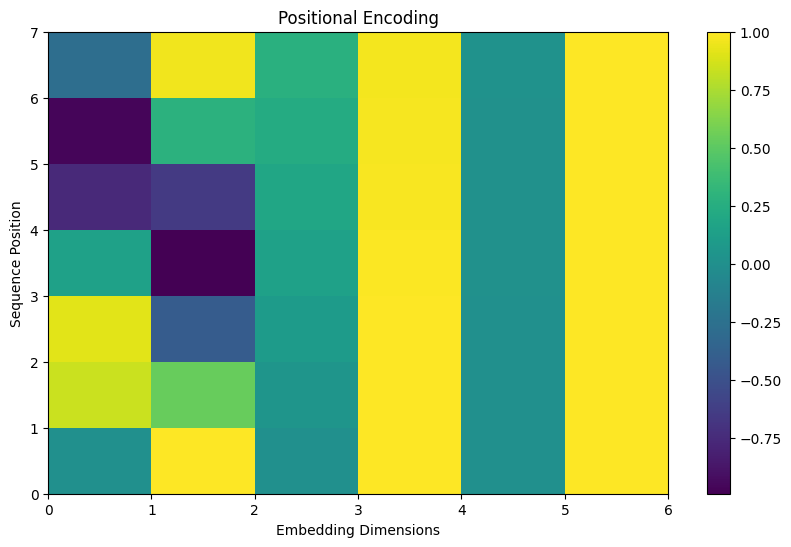

In [61]:
# Lista de palavras (sequência de entrada)
tokens = ["All", "hope", "abandon", "ye", "who", "enter", "in"]

# 1. Embeddings
vocab_size = 10  # Simulação de um vocabulário pequeno
embed_size = 6  # Dimensão do embedding
embedding_layer = nn.Embedding(vocab_size, embed_size)

# Mapear cada palavra para um índice (simulado)
word_to_idx = {word: i for i, word in enumerate(tokens)}
indices = torch.tensor([word_to_idx[word] for word in tokens])

# Gerar embeddings
embeddings = embedding_layer(indices)
print("Word Embeddings (Vetores densos de cada palavra):")
print(embeddings)

# 2. Positional Encoding
def positional_encoding(seq_len, embed_dim):
    pos = np.arange(seq_len)[:, np.newaxis]  # Posições (0, 1, ..., seq_len-1)
    i = np.arange(embed_dim)[np.newaxis, :]  # Dimensão do embedding (0, 1, ..., embed_dim-1)

    # Fórmula de Vaswani et al.
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / embed_dim)
    angle_rads = pos * angle_rates

    # Aplicar seno e cosseno
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  # Seno para índices pares
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  # Cosseno para índices ímpares
    return torch.tensor(angle_rads, dtype=torch.float32)

seq_len = len(tokens)
pos_encoding = positional_encoding(seq_len, embed_size)
print("\nPositional Encoding (Padrões senoide e cossenoide únicos para cada posição) \n \t [seno, cosseno, seno, cosseno, seno, cosseno, seno]:")
print("Senos notáveis. \n 0º = 0 \n 30º = 0,5 \n 45º = 0,7071 \n 60º = 0,8660 \n 90º - 1")
print("Cossenos notáveis. \n 0º = 1 \n 30º = 0,8660 \n 45º = 0,7071 \n 60º = 0,5 \n 90º - 0")
print(pos_encoding)

# 3. Combinação: Embeddings + Positional Encoding
final_representation = embeddings + pos_encoding
print("\nFinal Representation (A soma dos embeddings e do Positional Encoding):")
print(final_representation)

# 4. Visualização do Positional Encoding
plt.figure(figsize=(10, 6))
plt.pcolormesh(pos_encoding.numpy(), cmap="viridis")
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Sequence Position")
plt.show()


#### Self-Attention

- Calcula dependências entre todas as palavras de uma sequência.
- Três vetores principais:
  - **Query (Q)**: Qual token está "fazendo perguntas"?
  - **Key (K)**: Qual informação está disponível?
  - **Value (V)**: Qual resposta fornecer?
- Cálculo:
  $$
  \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
  $$

#### Multi-Head Attention

- Diversifica o foco do modelo com múltiplas "cabeças" de atenção paralelas.
  - Fórmula:
    
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O
$$


  - Onde cada cabeça é:
  
    $$
    \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
    $$

#### Feed-Forward

A Feedforward Network (FFN) é uma parte essencial de cada camada do Transformer (tanto no encoder quanto no decoder). Após a etapa de **Self-Attention**, cada vetor de token (que contém as informações semânticas e contextuais) é processado individualmente por essa rede.

* **Aplicada individualmente:** A FFN processa cada posição da sequência (ou seja, cada token) de forma independente. Não há troca de informações entre diferentes tokens nessa etapa.
* **Função principal:** Refinar a representação do token gerada pela etapa de atenção.

No Transformer, cada posição na sequência é representada por um vetor. Após a etapa de Self-Attention, cada vetor contém informações contextuais de todas as outras posições na sequência. A FFN:

* **Processa cada vetor separadamente:** Não altera o relacionamento entre os tokens, mas refina as informações contidas em cada vetor individualmente.
* **Paralelismo:** Como cada token é independente, a FFN pode ser aplicada em todos os tokens simultaneamente, aproveitando a capacidade das GPUs.

##### Feedforward Network no Transformer

A **Feedforward Network (FFN)** realiza duas transformações lineares em cada token individualmente:

---

###### Primeira Transformação Linear (Expansão da Dimensão):

$$ z = \text{ReLU}(xW_1 + b_1) $$

- \($ W_1 $): Matriz de pesos da primeira camada.
- \($b_1$): Vetor de bias da primeira camada.
- Dimensão da saída:
  $$
  d_{ff} = 4 \cdot d
  $$

---

###### Segunda Transformação Linear (Redução da Dimensão):

$$
y = zW_2 + b_2
$$

- \($W_2$): Matriz de pesos da segunda camada.
- \($b_2$): Vetor de bias da segunda camada.
- Retorna à dimensão original \($d$).

---

###### Por que essa estrutura é usada?

- **Expansão Temporária**: Permite ao modelo aprender padrões mais complexos em um espaço maior.
- **Redução Final**: Garante compatibilidade com outras partes do modelo e eficiência computacional.

---

###### Exemplo:

Se \($d = 64$) e \($d_{ff} = 256$):
- A entrada é um vetor de dimensão 64.
- A saída da primeira camada será um vetor de dimensão 256.
- A saída final retorna à dimensão 64.


#### Normalização e Drop-out

**Layer Normalization (Norm)** é uma técnica que normaliza os valores em cada **posição do vetor** (ou token) de forma independente, garantindo que todas as dimensões tenham uma média e variância consistentes.

##### **Por que usar Layer Normalization?**
1. **Estabilidade do Treinamento**:
   - Reduz a variabilidade dos valores intermediários em redes profundas, garantindo que os gradientes fluam bem.
2. **Aceleração da Convergência**:
   - Manter os valores normalizados acelera o aprendizado.
3. **Independência de Batch Size**:
   - Ao contrário de **Batch Normalization**, a LayerNorm calcula a média e variância **dentro de cada vetor**, permitindo seu uso em batch sizes pequenos.

##### **Fórmula Matemática**
Dado um vetor de entrada $x$ com $d$ dimensões:

$$
\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

**Onde:**
- $\mu$: Média dos valores em $x$.
- $\sigma^2$: Variância dos valores em $x$.
- $\epsilon$: Pequeno valor para evitar divisão por zero.
- $\gamma$: Fator de escala treinável.
- $\beta$: Fator de deslocamento treinável.

---

#### **Dropout**

**Dropout** é uma técnica de regularização que **desativa aleatoriamente algumas unidades** de uma camada durante o treinamento.

##### **Por que usar Dropout?**
1. **Prevenção de Overfitting**:
   - Desativar unidades obriga o modelo a generalizar melhor.
2. **Regularização Implícita**:
   - Promove redundância no aprendizado ao distribuir a importância entre várias conexões.

##### **Como funciona o Dropout?**
Durante o treinamento:
1. Uma máscara binária $m$ é gerada aleatoriamente para cada unidade.
2. A saída da unidade é multiplicada pela máscara:

$$
y = x \cdot m
$$

No momento da inferência, o Dropout é desativado, e os pesos são escalados por $1 - p$, onde $p$ é a taxa de Dropout.

---

#### **Combinação no Transformer**

1. **Layer Normalization**:
   - Aplicada após o Self-Attention e Feedforward Network para estabilizar as ativações e melhorar o fluxo de gradientes.

2. **Dropout**:
   - Adicionado:
     - Após o Self-Attention (antes da soma residual).
     - Após a Feedforward Network (antes da soma residual).
     - Opcionalmente nos embeddings de entrada.

---

#### **Exemplo Visual**

Considere uma entrada de Self-Attention de 3 tokens, com embeddings de dimensão 4:

$$
x = \begin{bmatrix}
0.5 & 1.2 & -0.3 & 0.8 \\
0.1 & 0.9 & 0.7 & -0.4 \\
1.1 & -0.6 & 0.3 & 0.5
\end{bmatrix}
$$

1. **Layer Normalization**:
   - Para cada linha (token), calcule a média e variância.
   - Normalize os valores:
   
$$x_{\text{norm}} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

2. **Dropout**:
   - Durante o treinamento, desative algumas dimensões aleatoriamente:

$$x_{dropout} = \begin{bmatrix}
     0.5 & 0 & -0.3 & 0.8 \\
     0.1 & 0.9 & 0 & -0.4 \\
     0 & -0.6 & 0.3 & 0.5
     \end{bmatrix}
$$

---

#### **Resumo**

1. **Layer Normalization**:
   - Estabiliza o treinamento.
   - Melhora o fluxo de gradientes.
   - Funciona por posição, não por batch.

2. **Dropout**:
   - Reduz overfitting.
   - Promove a generalização.
   - Adicionado após Self-Attention e Feedforward Network.


#### Arquitetura Geral

O Transformer consiste em duas partes principais:

* **Encoder:** Processa a entrada e cria uma representação contextual.
* **Decoder:** Gera a sequência de saída usando a representação do encoder.

Cada parte é composta por **N camadas idênticas**, com dois blocos principais:

* **Mecanismo de Atenção Multi-Head**.
* **Feedforward Position-Wise:** Rede neural densa aplicada individualmente em cada posição.

##### Estrutura Encoder/Decoder

**1. O Papel do Encoder (Codificador)**
O encoder recebe como entrada uma sequência, como uma frase ou parágrafo, e cria uma representação compacta e contextual dessa sequência. Essa representação captura:

  * O significado de cada elemento (token) na sequência.
  * Relações entre tokens (dependências locais e globais).

**Como o Encoder trabalha:**

1. Recebe a entrada: Uma sequência de tokens (como palavras, subpalavras ou caracteres), que são transformados em embeddings numéricos.
2. Adiciona Positional Encodings: Os embeddings são combinados com informações posicionais para preservar a ordem das palavras.
2. Aplica Self-Attention:
  * Cada palavra "presta atenção" em todas as outras da sequência.
  * Calcula dependências de curto e longo alcance entre palavras.
4. Feedforward Network: Após o self-attention, uma rede neural densa refina as representações individuais de cada posição.
5. Repete o processo: Isso é feito por várias camadas de encoder (geralmente 6 ou 12).

**Saída do Encoder:**

  * O encoder retorna uma matriz de vetores que representam o contexto completo da sequência de entrada. Essa matriz será usada pelo decoder para gerar a saída.

**2. O Papel do Decoder (Decodificador)**

O decoder usa a saída do encoder para gerar uma sequência de saída, token por token. Ele é essencial em tarefas onde o modelo precisa criar algo novo, como traduzir uma frase ou responder a uma pergunta.

**Como o Decoder trabalha:**

1. Recebe dois tipos de entrada:
  * A representação do encoder (contexto da entrada).
  * Os tokens gerados até o momento pela própria saída do decoder.
2. Masked Self-Attention:
  * O decoder usa atenção em sua própria saída, mas com máscara para evitar "espiar" tokens futuros (forçando a geração sequencial).
3. Cross-Attention:
  * O decoder presta atenção nos vetores gerados pelo encoder. Isso ajuda a focar partes relevantes da entrada.
4. Feedforward Network:
  * Assim como no encoder, os vetores passam por uma camada densa para refinar a saída.
5. Repete o processo:
  * Este ciclo ocorre por várias camadas do decoder (geralmente 6 ou 12).

**Saída do Decoder:**

  * O decoder gera um vetor que é transformado em uma probabilidade sobre o vocabulário, escolhendo qual token será o próximo na sequência.

**3. Fluxo Completo do Encoder-Decoder**

1. Entrada: O encoder recebe a sequência inicial (ex.: "Eu gosto de aprender").
2. Representação Abstrata: O encoder cria uma representação contextual (ex.: relação entre "Eu" e "gosto").
3. Decoder:
  * Recebe a saída do encoder e o histórico dos tokens gerados.
  * Gera um token de saída por vez (ex.: "I", depois "like", depois "to learn").
4. Repetição: O processo se repete até que o modelo produza o símbolo de parada.

**4. Forma análoga**

* **Encoder:** Imagine que você lê um parágrafo e escreve um resumo para guardar as ideias principais.
* **Decoder:** Usando esse resumo, você cria um texto traduzido ou reescreve o parágrafo com outras palavras.

Por exemplo, na tradução automática de *Eu gosto de aprender* para *I like to learn*:

  * O encoder transforma "Eu gosto de aprender" em uma representação numérica rica.
  * O decoder usa essa representação para gerar "I", "like", "to", e "learn", palavra por palavra, mantendo a coerência com o significado da entrada.
  
Essa separação de responsabilidades é o que torna a arquitetura Encoder-Decoder tão poderosa.

In [62]:
from transformers import MBartForConditionalGeneration, MBart50Tokenizer

# Carregar o modelo mBART-50
model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50Tokenizer.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

# Configurar o idioma de destino para Português
tokenizer.src_lang = "en_XX"
texts = [
    "Through me the way is to the city of sorrow; through me the way is to eternal woe.",
    "Justice incited my sublime Creator; created me divine Omnipotence.",
    "All hope abandon, ye who enter here!",
    "I love learning about Transformers and natural language processing.",
    "This text will be translated from English to Portuguese using a Transformer model."
]

# Tradução
print("mBART-50 Translations:")
for text in texts:
    inputs = tokenizer(text, return_tensors="pt")
    translated_tokens = model.generate(**inputs, forced_bos_token_id=tokenizer.lang_code_to_id["pt_XX"])
    translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
    print(f"Original: {text}")
    print(f"Translated: {translated_text}")
    print("-" * 50)


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

mBART-50 Translations:
Original: Through me the way is to the city of sorrow; through me the way is to eternal woe.
Translated: Através de mim é o caminho para a cidade da tristeza; Através de mim é o caminho para a maldade eterna.
--------------------------------------------------
Original: Justice incited my sublime Creator; created me divine Omnipotence.
Translated: A justiça incitau o meu sublime Criador; criou-me a Omnipotência divina.
--------------------------------------------------
Original: All hope abandon, ye who enter here!
Translated: Todos abandonem a esperança, vocês que entram aqui!
--------------------------------------------------
Original: I love learning about Transformers and natural language processing.
Translated: Adoro aprender sobre Transformers e processamento de linguagem natural.
--------------------------------------------------
Original: This text will be translated from English to Portuguese using a Transformer model.
Translated: Este texto será traduzid

In [63]:
from transformers import pipeline

# Configuração do pipeline
# Usamos o pipeline Hugging Face para simplificar o uso do Transformer
classifier = pipeline("sentiment-analysis")

# Exemplos de texto
texts = [
    "I love this product! It's amazing and works perfectly.",
    "This is the worst experience I've ever had. Terrible service.",
    "The movie was okay, not great but not bad either.",
    "Absolutely fantastic! Would highly recommend it to everyone.",
    "I wouldn't recommend this to anyone. It was a waste of money."
]

# Classificação de Sentimentos
print("Sentiment Analysis Results:")
for text in texts:
    result = classifier(text)[0]
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']}, Score: {result['score']:.4f}")
    print("-" * 50)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Analysis Results:
Text: I love this product! It's amazing and works perfectly.
Sentiment: POSITIVE, Score: 0.9999
--------------------------------------------------
Text: This is the worst experience I've ever had. Terrible service.
Sentiment: NEGATIVE, Score: 0.9997
--------------------------------------------------
Text: The movie was okay, not great but not bad either.
Sentiment: POSITIVE, Score: 0.9919
--------------------------------------------------
Text: Absolutely fantastic! Would highly recommend it to everyone.
Sentiment: POSITIVE, Score: 0.9999
--------------------------------------------------
Text: I wouldn't recommend this to anyone. It was a waste of money.
Sentiment: NEGATIVE, Score: 0.9998
--------------------------------------------------


# BERT - Bidirectional Encoder Representations for Transformers

## Devlin et al (2018) - BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

* O artigo apresenta o BERT como o primeiro modelo de linguagem baseado em Transformers totalmente bidirecional.
* Ele destaca as principais inovações do BERT, como:
  * Treinamento bidirecional;
  * Uso de mascaramento de palavras (Masked Language Modeling - MLM);
  * Modelagem de próxima sentença (Next Sentence Prediction - NSP).
* Mostra como o BERT alcançou resultados de ponta em várias tarefas de NLP, como classificação de sentenças e resposta a perguntas.

### 1. O que é o BERT?

* Modelo revolucionário de NLP introduzido pelo Google AI em 2018.
* Pré-treinado em grandes quantidades de texto, como livros e artigos da Wikipedia.
* Seu principal diferencial é a compreensão bidirecional do texto, o que significa que ele analisa uma palavra considerando tanto o contexto anterior quanto o posterior.

* Principais aplicações:

  * Resposta a perguntas: usado em assistentes virtuais para interpretar e responder perguntas.
  * Análise de sentimentos: classifica textos como positivos, negativos ou neutros.
  * Reconhecimento de entidades nomeadas: identifica nomes de pessoas, lugares, organizações, etc.
  * Tradução automática: melhora a qualidade de traduções contextualizadas.

### 2. A base do BERT: Transformer

* O BERT usa apenas o CODIFICADOR do Transformer, que é uma arquitetura introduzida pelo artigo "Attention is All You Need", que possui CODIFICADOR E DECODIFICADOR;
* Como o Transformer funciona:
  * Autoatenção: Identifica quais palavras de uma frase são mais relevantes para entender o significado de uma palavra específica.
      * Exemplo: Em "Ela foi ao parque com seu cachorro", "seu" se refere a "Ela".
  * Codificação: Cria representações vetoriais (embeddings) do texto que capturam o significado contextual das palavras.
* Por usar autoatenção, o BERT captura relações complexas entre palavras em frases longas.

#### Por que o BERT usa apenas o Codificador?

1. Objetivo principal do BERT: Representação contextual

  * O propósito do BERT é criar representações ricas e contextualizadas para palavras em um texto, capturando relações complexas entre elas.
  * O codificador é ideal para isso porque:
    * Ele considera todas as palavras da sequência simultaneamente (graças à autoatenção bidirecional).
    * Isso permite capturar o significado de uma palavra com base em todo o contexto da frase (tanto anterior quanto posterior).

2. Decodificador é desnecessário para o BERT

  * O decodificador do Transformer é usado em tarefas onde há necessidade de gerar texto de saída (por exemplo, tradução automática ou modelos como GPT).
  * No caso do BERT, não é necessário gerar texto. Ele é projetado para tarefas de compreensão, como:
    * Classificação de texto.
    * Resposta a perguntas.
    * Reconhecimento de entidades.
  * Portanto, incluir o decodificador seria redundante e aumentaria desnecessariamente a complexidade computacional.

3. Treinamento bidirecional no codificador

  * O codificador do Transformer no BERT é ajustado para ser bidirecional:
    * Ele processa o texto de entrada olhando para os dois lados (anterior e posterior) de cada palavra.
    * Isso seria incompatível com o decodificador, que geralmente é projetado para processar texto de forma sequencial e unidirecional (da esquerda para a direita).

### 3. Características principais do BERT

1. Pré-treinamento e ajuste fino:
  * Pré-treinado em tarefas gerais e ajustado (fine-tuning) em dados específicos para resolver problemas como análise de texto médico ou busca.
2. Masked Language Modeling (MLM):
  * Durante o treinamento, o modelo "mascara" (oculta) algumas palavras e aprende a prever essas palavras com base no contexto.
  * Exemplo: "O BERT é um [MASK] poderoso." → Predição: "modelo".
3. Next Sentence Prediction (NSP):
  * Ensina o modelo a prever se uma frase segue outra logicamente.
  * Exemplo:
    * Frase 1: "Eu adoro programação."
    * Frase 2: "Por isso, estudei Python."
  * O modelo aprende que há uma relação lógica.

### 4. Como o BERT funciona no pré-treinamento?

1. Masked Language Modeling (MLM):
  *Objetivo: Fazer o modelo entender o contexto das palavras em frases.
  * Técnica: Substituir 15% das palavras por um token especial [MASK].
  * Exemplo:
    * Entrada: "O cachorro está [MASK] no parque."
    * Saída esperada: "brincando".
2. Next Sentence Prediction (NSP):
  * Objetivo: Ensinar o modelo a entender a sequência lógica de sentenças.
  * Técnica:
    * Dado um par de sentenças, identificar se a segunda segue logicamente a primeira.
    * Exemplo:
      * Entrada: ("Eu estou com fome.", "Vou comer algo.") → "Sim"
      * Entrada: ("Eu estou com fome.", "A lua está cheia.") → "Não".

### 5. Estrutura do modelo BERT

A entrada para o modelo BERT é composta por três componentes principais:

1. Tokens:
  * O texto é convertido em tokens, que são palavras ou pedaços de palavras.
  * Exemplo: "brincando" pode ser dividido em ["brinc", "ando"].
2. Segment embeddings:
  * Usados para diferenciar entre duas frases quando o modelo processa pares de sentenças.
3. Position embeddings:
  * Indicam a posição de cada token na frase para preservar a ordem das palavras.

### 6. Ajuste fino para uma tarefa específica

O modelo BERT pré-treinado pode ser ajustado para uma tarefa específica, como classificação de texto, resposta a perguntas ou reconhecimento de entidades nomeadas (NER). Isso é feito adicionando uma camada no topo do modelo e treinando com dados rotulados.

Um EXEMPLO (NÃO É CÓDIGO FINAL PARA PROJETO!) de ajuste fino para classificação de texto

In [64]:
!pip install datasets

In [65]:
# EXECUTAR_DEMO_CLASSIFICACAO: célula de DEMONSTRAÇÃO GENÉRICA (não faz parte da entrega do
# projeto DL-2024). Fica DESLIGADA por padrão para o notebook rodar rápido.
# Para executá-la (é pesada e pode levar bastante tempo mesmo com GPU), troque
# para True.
EXECUTAR_DEMO_CLASSIFICACAO = False

if EXECUTAR_DEMO_CLASSIFICACAO:
    import os
    import sys
    import torch
    import datasets.config

    from transformers import (
        BertTokenizer,
        BertForSequenceClassification,
        Trainer,
        TrainingArguments
    )

    from datasets import load_dataset

    # Desativa wandb antes de criar o Trainer
    os.environ["WANDB_DISABLED"] = "true"

    # Correção para erro do torchvision no Colab:
    # ImportError: cannot import name 'VideoReader' from torchvision.io
    datasets.config.TORCHVISION_AVAILABLE = False

    for module_name in list(sys.modules.keys()):
        if module_name.startswith("torchvision"):
            del sys.modules[module_name]

    # Verifique se a GPU está disponível
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print(f"Using device: {device}")

    # Carregando o tokenizer e o modelo pré-treinado
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

    model.to(device)

    # Dataset IMDB no Hugging Face
    dataset = load_dataset("stanfordnlp/imdb")

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=512
        )

    # Tokenização
    tokenized_dataset = dataset.map(tokenize, batched=True)

    # Usaremos apenas os splits supervisionados
    train_dataset = tokenized_dataset["train"]
    eval_dataset = tokenized_dataset["test"]

    # Remove coluna de texto original
    train_dataset = train_dataset.remove_columns(["text"])
    eval_dataset = eval_dataset.remove_columns(["text"])

    # Garante que as colunas tenham os nomes esperados pelo Trainer
    train_dataset = train_dataset.rename_column("label", "labels")
    eval_dataset = eval_dataset.rename_column("label", "labels")

    # Seleciona apenas as colunas necessárias
    columns = ["input_ids", "attention_mask", "labels"]

    train_dataset = train_dataset.select_columns(columns)
    eval_dataset = eval_dataset.select_columns(columns)

    # Formato torch aplicado separadamente em cada split
    train_dataset = train_dataset.with_format("torch")
    eval_dataset = eval_dataset.with_format("torch")

    # Configurando os argumentos de treinamento
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        run_name="ajuste_Fino",
        logging_steps=100,
        save_total_limit=2,
        load_best_model_at_end=True,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    # Configurando o Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
    )

    # Treinando o modelo
    trainer.train()
else:
    print("Célula desligada (EXECUTAR_DEMO_CLASSIFICACAO=False) - demo genérica de classificação IMDB, não faz parte do projeto DL-2024. Pulando para economizar tempo.")


Célula desligada (EXECUTAR_DEMO_CLASSIFICACAO=False) - demo genérica de classificação IMDB, não faz parte do projeto DL-2024. Pulando para economizar tempo.


###7. Treinamento contínuo (Transfer Learning)

Se você tiver um domínio específico, como medicina ou finanças, pode continuar treinando o BERT em um corpus de texto desse domínio antes do ajuste fino.

####Requisitos e Considerações de Formatação

1. Formato do arquivo de texto:

  * O corpus deve estar em formato texto puro (.txt).
  * Cada linha do arquivo representa uma entrada independente para o modelo.

2. Estrutura do texto:

  * Frases devem ser completas e coerentes.
  * O texto não precisa estar tokenizado previamente; o tokenizer do BERT fará isso.
  * Não insira quebras de linha dentro de uma entrada.

In [66]:
# EXECUTAR_DEMO_MLM: célula de DEMONSTRAÇÃO GENÉRICA (não faz parte da entrega do
# projeto DL-2024). Fica DESLIGADA por padrão para o notebook rodar rápido.
# Para executá-la (é pesada e pode levar bastante tempo mesmo com GPU), troque
# para True.
EXECUTAR_DEMO_MLM = False

if EXECUTAR_DEMO_MLM:
    import os
    import sys
    import glob
    import random
    import torch
    from transformers import BertTokenizer, BertForMaskedLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling
    from datasets import load_dataset

    # Verifique se a GPU está disponível
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print(f"Usando dispositivo: {device}")

    # ---------------------------------------------------------------------
    # CORREÇÃO: 'seu_corpus.txt' era um nome de arquivo placeholder que nunca
    # existia de fato, causando FileNotFoundError. Agora o corpus é gerado
    # automaticamente a partir do próprio dataset DL-2024 usado no projeto,
    # reduzindo a amostra de ~4000 para 1000 textos, para este exemplo didático
    # de continued pretraining (MLM) rodar bem mais rápido.
    # ---------------------------------------------------------------------
    CAMINHO_CORPUS = "seu_corpus.txt"
    N_LINHAS_CORPUS = 1000  # reduzido de ~4000 para ~1000 textos, para acelerar o treino

    def localizar_arquivo_tabular_dl2024():
        """Localiza um arquivo tabular do dataset DL-2024, priorizando o dataset já
        anexado ao notebook do Kaggle (/kaggle/input) e só recorrendo ao kagglehub
        (que exige internet habilitada) se necessário. Extensões são comparadas em
        minúsculas para não perder arquivos como 'Dataset.CSV'.
        """
        extensoes = (".csv", ".tsv", ".json", ".jsonl", ".xlsx", ".parquet")

        candidatos_raiz = []
        if os.path.isdir("/kaggle/input"):
            candidatos_raiz.append("/kaggle/input")

        try:
            import kagglehub
            dataset_path_demo = kagglehub.dataset_download("georgekurokijr/dl-2024")
            candidatos_raiz.append(dataset_path_demo)
        except Exception as exc:
            print(f"Aviso: kagglehub não conseguiu baixar o dataset ({exc}).")

        arquivos_encontrados = []
        for raiz in candidatos_raiz:
            for caminho in glob.glob(os.path.join(raiz, "**", "*"), recursive=True):
                if os.path.isfile(caminho) and caminho.lower().endswith(extensoes):
                    arquivos_encontrados.append(caminho)

        if not arquivos_encontrados:
            # Ajuda a depurar: mostra o que de fato existe nas pastas candidatas.
            print("Não encontrei arquivos tabulares. Conteúdo das pastas candidatas:")
            for raiz in candidatos_raiz:
                for caminho in glob.glob(os.path.join(raiz, "**", "*"), recursive=True):
                    print(" -", caminho)
            raise FileNotFoundError(
                "Não foi possível localizar um arquivo tabular do dataset DL-2024 "
                "(nem em /kaggle/input, nem via kagglehub) para montar o corpus."
            )

        return arquivos_encontrados[0]


    def ler_tabela(caminho: str):
        import pandas as pd
        lower = caminho.lower()
        if lower.endswith(".csv"):
            return pd.read_csv(caminho, encoding="latin-1", sep=None, engine="python")
        if lower.endswith(".tsv"):
            return pd.read_csv(caminho, encoding="latin-1", sep="\t", engine="python")
        if lower.endswith(".jsonl"):
            return pd.read_json(caminho, lines=True)
        if lower.endswith(".json"):
            return pd.read_json(caminho)
        if lower.endswith(".xlsx"):
            return pd.read_excel(caminho)
        if lower.endswith(".parquet"):
            return pd.read_parquet(caminho)
        raise ValueError(f"Formato não suportado: {caminho}")


    if not os.path.exists(CAMINHO_CORPUS):
        print("Gerando corpus a partir do dataset DL-2024...")

        arquivo_encontrado = localizar_arquivo_tabular_dl2024()
        print("Arquivo usado para montar o corpus:", arquivo_encontrado)

        df_corpus = ler_tabela(arquivo_encontrado)

        colunas_texto = [c for c in df_corpus.columns if df_corpus[c].dtype == "object"]
        if not colunas_texto:
            raise ValueError("Nenhuma coluna textual encontrada para montar o corpus.")

        textos = df_corpus[colunas_texto[0]].dropna().astype(str).tolist()
        if len(colunas_texto) > 1:
            textos += df_corpus[colunas_texto[1]].dropna().astype(str).tolist()

        random.Random(42).shuffle(textos)
        textos = [t.strip() for t in textos if len(t.strip()) > 10][:N_LINHAS_CORPUS]

        with open(CAMINHO_CORPUS, "w", encoding="utf-8") as f:
            f.write("\n".join(textos))

        print(f"Corpus gerado com {len(textos)} linhas em '{CAMINHO_CORPUS}'.")
    else:
        print(f"Usando corpus já existente em '{CAMINHO_CORPUS}'.")

    # Carregando o modelo e tokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertForMaskedLM.from_pretrained('bert-base-uncased')
    model.to(device)  # Move o modelo para a GPU, se disponível

    # Carregando o corpus personalizado (agora existente)
    dataset = load_dataset('text', data_files={'train': CAMINHO_CORPUS})

    # Tokenizando o dataset.
    # max_length reduzido de 512 para 128: os textos são curtos/médios, e isso
    # reduz bastante o tempo de treinamento sem perda relevante de conteúdo.
    def tokenize(batch):
        return tokenizer(
            batch['text'],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_special_tokens_mask=True,
        )

    tokenized_dataset = dataset.map(tokenize, batched=True)
    tokenized_dataset = tokenized_dataset.remove_columns(['text'])
    tokenized_dataset.set_format(type='torch')

    # Adicionando DataCollator para MLM
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=0.15
    )

    # Configurando os argumentos de treinamento.
    # - num_train_epochs reduzido de 3 para 1: suficiente para o propósito didático
    #   de demonstrar continued pretraining, sem repetir 3x um treino já mais rápido.
    # - batch maior quando há GPU, já que 1000 exemplos cabem tranquilamente.
    # - fp16 só é ativado se realmente houver GPU (em CPU causaria erro/lentidão).
    # - save_strategy="no": o modelo final já é salvo manualmente ao fim da célula,
    #   então não é necessário salvar checkpoints intermediários (economiza tempo).
    training_args = TrainingArguments(
        output_dir='./results',
        overwrite_output_dir=True,
        num_train_epochs=1,
        per_device_train_batch_size=16 if torch.cuda.is_available() else 8,
        save_strategy="no",
        logging_dir='./logs',
        logging_steps=20,
        run_name="custom_dataset",  # Nome do experimento
        fp16=torch.cuda.is_available(),  # Treinamento em ponto flutuante de 16 bits, só em GPU
        report_to="none",
    )

    # Configurando o Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset['train'],
        data_collator=data_collator
    )

    # Treinando o modelo
    trainer.train()
    model.save_pretrained('./custom_bert')
    tokenizer.save_pretrained('./custom_bert')

    print("Treinamento concluído. Modelo salvo em ./custom_bert")

else:
    print("Célula desligada (EXECUTAR_DEMO_MLM=False) - demo genérica de continued pretraining (MLM), não faz parte do projeto DL-2024. Pulando para economizar tempo.")


Célula desligada (EXECUTAR_DEMO_MLM=False) - demo genérica de continued pretraining (MLM), não faz parte do projeto DL-2024. Pulando para economizar tempo.


3. Para tarefas específicas

  * Se o corpus incluir pares de sentenças (como na tarefa de Next Sentence Prediction - NSP), você pode formatar o texto com uma separação explícita (por exemplo, usando tabulação ou separadores). Porém, isso geralmente é desnecessário para transfer learning básico com Masked Language Modeling (MLM).

#####Formatando pares de sentenças para NSP

O corpus deve conter pares de sentenças separados por um tabulador (\t) ou outro delimitador, e um rótulo que indica:

* 1 para "a segunda sentença segue logicamente a primeira".
* 0 para "a segunda sentença não segue a primeira".

`O BERT é amplamente usado em NLP. \t Ele é baseado na arquitetura Transformer. \t	1`

`O modelo foi treinado na Wikipedia. \t É usado para classificação de imagens. \t	0`

`Treinamento de modelos exige GPUs poderosas. \t Grandes datasets são necessários. \t	1`

`O céu está limpo hoje. \t A previsão é de tempestades. \t	0`

`Eu gosto de programar em Python. \t É por isso que estou aprendendo NLP. \t	1`

**Como usar o corpus no Hugging Face**

Após criar o arquivo, você pode carregá-lo usando a biblioteca Hugging Face Datasets:

In [67]:
# EXECUTAR_DEMO_NSP: célula de DEMONSTRAÇÃO GENÉRICA (não faz parte da entrega do
# projeto DL-2024). Fica DESLIGADA por padrão para o notebook rodar rápido.
# Para executá-la (é pesada e pode levar bastante tempo mesmo com GPU), troque
# para True.
EXECUTAR_DEMO_NSP = False

if EXECUTAR_DEMO_NSP:
    import torch
    from datasets import load_dataset
    from transformers import BertTokenizer, BertForNextSentencePrediction, Trainer, TrainingArguments

    # Verifique se a GPU está disponível
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print(f"Usando dispositivo: {device}")

    # Carregar o corpus formatado para NSP
    dataset = load_dataset(
        "csv",
        data_files={"train": "seu_corpus_nsp.txt"},
        delimiter="\t",
        column_names=["sentence_A", "sentence_B", "label"]
    )

    # Verificar as primeiras linhas para validação
    print(dataset['train'][:5])

    # Carregar o tokenizer do BERT
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    # Tokenizar e preprocessar as sentenças
    def preprocess(batch):
        tokenized_batch = tokenizer(
            batch["sentence_A"],
            batch["sentence_B"],
            padding="max_length",
            truncation=True,
            max_length=512
        )
        tokenized_batch["labels"] = list(map(int, batch["label"]))  # Converter rótulos para inteiros
        return tokenized_batch

    # Aplicar tokenização e preparar dataset
    tokenized_dataset = dataset.map(preprocess, batched=True)
    tokenized_dataset = tokenized_dataset.remove_columns(["sentence_A", "sentence_B", "label"])
    tokenized_dataset.set_format(type="torch")

    # Carregar o modelo de NSP e mover para o dispositivo
    model = BertForNextSentencePrediction.from_pretrained("bert-base-uncased")
    model.to(device)

    # Configurar argumentos de treinamento
    training_args = TrainingArguments(
        output_dir="./results",
        overwrite_output_dir=True,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        save_steps=500,
        save_total_limit=2,
        eval_strategy="epoch",  # CORREÇÃO: parâmetro renomeado nesta versão
        logging_dir="./logs",
        fp16=True,  # Ativar treino em ponto flutuante de 16 bits para GPUs modernas
    )

    # Configurar o Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
    )

    # Treinando o modelo
    trainer.train()

    # Salvar o modelo final
    model.save_pretrained("./nsp_model")
    tokenizer.save_pretrained("./nsp_model")

else:
    print("Célula desligada (EXECUTAR_DEMO_NSP=False) - demo genérica de Next Sentence Prediction, não faz parte do projeto DL-2024. Pulando para economizar tempo.")


Célula desligada (EXECUTAR_DEMO_NSP=False) - demo genérica de Next Sentence Prediction, não faz parte do projeto DL-2024. Pulando para economizar tempo.


###8. Adicionando camadas personalizadas

Para tarefas específicas, como múltiplas classificações ou tarefas multilabel, você pode adicionar camadas personalizadas ao topo do BERT.

In [68]:
import torch
from torch import nn
from torch.optim import AdamW  # CORREÇÃO: AdamW foi removido de transformers, agora vem de torch.optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertModel, BertTokenizer, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Configurações principais
MAX_LEN = 128  # Comprimento máximo dos textos
BATCH_SIZE = 8  # Tamanho do batch
EPOCHS = 3  # Número de épocas
LR = 5e-5  # Taxa de aprendizado

# Definindo o dispositivo (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Classe para o Dataset
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenizando o texto
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Modelo personalizado baseado no BERT
class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        return self.classifier(cls_output)

# Função de treinamento
def train_model(model, data_loader, optimizer, criterion, lr_scheduler):
    model.train()
    total_loss = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

# Função de avaliação
def evaluate_model(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy

# Dados de exemplo (substituir por dados reais)
data = {
    "texts": [
        "O BERT é uma revolução no NLP.",
        "A previsão do tempo indica chuva amanhã.",
        "Python é uma ótima linguagem de programação.",
        "O filme foi incrível e emocionante.",
        "Hoje vou estudar Machine Learning."
    ],
    "labels": [0, 1, 2, 0, 2]  # Classes (0, 1, 2)
}

# Convertendo para DataFrame
df = pd.DataFrame(data)

# Dividindo os dados em treino e teste
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["texts"].values,
    df["labels"].values,
    test_size=0.2,
    random_state=42
)

# Carregando o tokenizer do BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Criando datasets e data loaders
train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Criando o modelo
model = CustomBERTModel(num_labels=3)  # 3 classes
model = model.to(device)

# Configurando o otimizador e a função de perda
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Configurando o agendador de taxa de aprendizado
num_training_steps = len(train_loader) * EPOCHS
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# Loop de treinamento
for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss = train_model(model, train_loader, optimizer, criterion, lr_scheduler)
    val_accuracy = evaluate_model(model, val_loader)
    end_time = time.time()

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Treinamento: Loss = {train_loss:.4f}")
    print(f"Validação: Accuracy = {val_accuracy:.4f}")
    print(f"Tempo: {end_time - start_time:.2f} segundos\n")

# Salvar o modelo e tokenizer
torch.save(model.state_dict(), "bert_model.pth")
tokenizer.save_pretrained("bert_tokenizer")

# Testando com novos dados
test_texts = ["A previsão do tempo é para amanhã.", "BERT é um modelo poderoso."]
test_dataset = TextDataset(test_texts, [0, 0], tokenizer, MAX_LEN)  # Labels fictícios
test_loader = DataLoader(test_dataset, batch_size=1)

# Predizendo classes
model.eval()
predictions = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())

print(f"Predições: {predictions}")


Usando dispositivo: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3
Treinamento: Loss = 1.0087
Validação: Accuracy = 0.0000
Tempo: 0.23 segundos

Epoch 2/3
Treinamento: Loss = 0.8379
Validação: Accuracy = 0.0000
Tempo: 0.13 segundos

Epoch 3/3
Treinamento: Loss = 0.7455
Validação: Accuracy = 0.0000
Tempo: 0.13 segundos

Predições: [np.int64(2), np.int64(2)]


# BERTimbau - Souza, Nogueira e Lotufo (2020)

Variante do BERT ajustada especificamente para Processamento de Linguagem Natural (NLP) em português, e foi desenvolvido pela comunidade científica brasileira. O BERTimbau é treinado com dados em português, como a Wikipedia em português, livros e outros textos de domínio público.

## Diferenciais do BERTimbau

1. Idioma nativo: Foi treinado exclusivamente para lidar com os desafios do português, como flexões verbais e diferenças de gênero e número.
2. Baseado no BERT original: Segue a mesma arquitetura do BERT, mas com corpus específico para o português.
3. Modelos disponíveis:
  * `bert-base-portuguese-cased`: Sensível a maiúsculas/minúsculas.
  * `bert-base-portuguese-uncased`: Não sensível a maiúsculas/minúsculas.

In [69]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline

# Carregar o modelo para Masked Language Modeling
model = AutoModelForMaskedLM.from_pretrained('neuralmind/bert-base-portuguese-cased')
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [70]:
# Configurar o pipeline
pipe = pipeline('fill-mask', model=model, tokenizer=tokenizer)

# Usar o pipeline para preencher a máscara
result = pipe('Tinha uma [MASK] no meio do caminho.')
for prediction in result:
    print(f"Palavra: {prediction['token_str']}, Probabilidade: {prediction['score']}")

Palavra: pedra, Probabilidade: 0.14287784695625305
Palavra: árvore, Probabilidade: 0.062133628875017166
Palavra: estrada, Probabilidade: 0.0551498681306839
Palavra: casa, Probabilidade: 0.029918791726231575
Palavra: cruz, Probabilidade: 0.025660378858447075


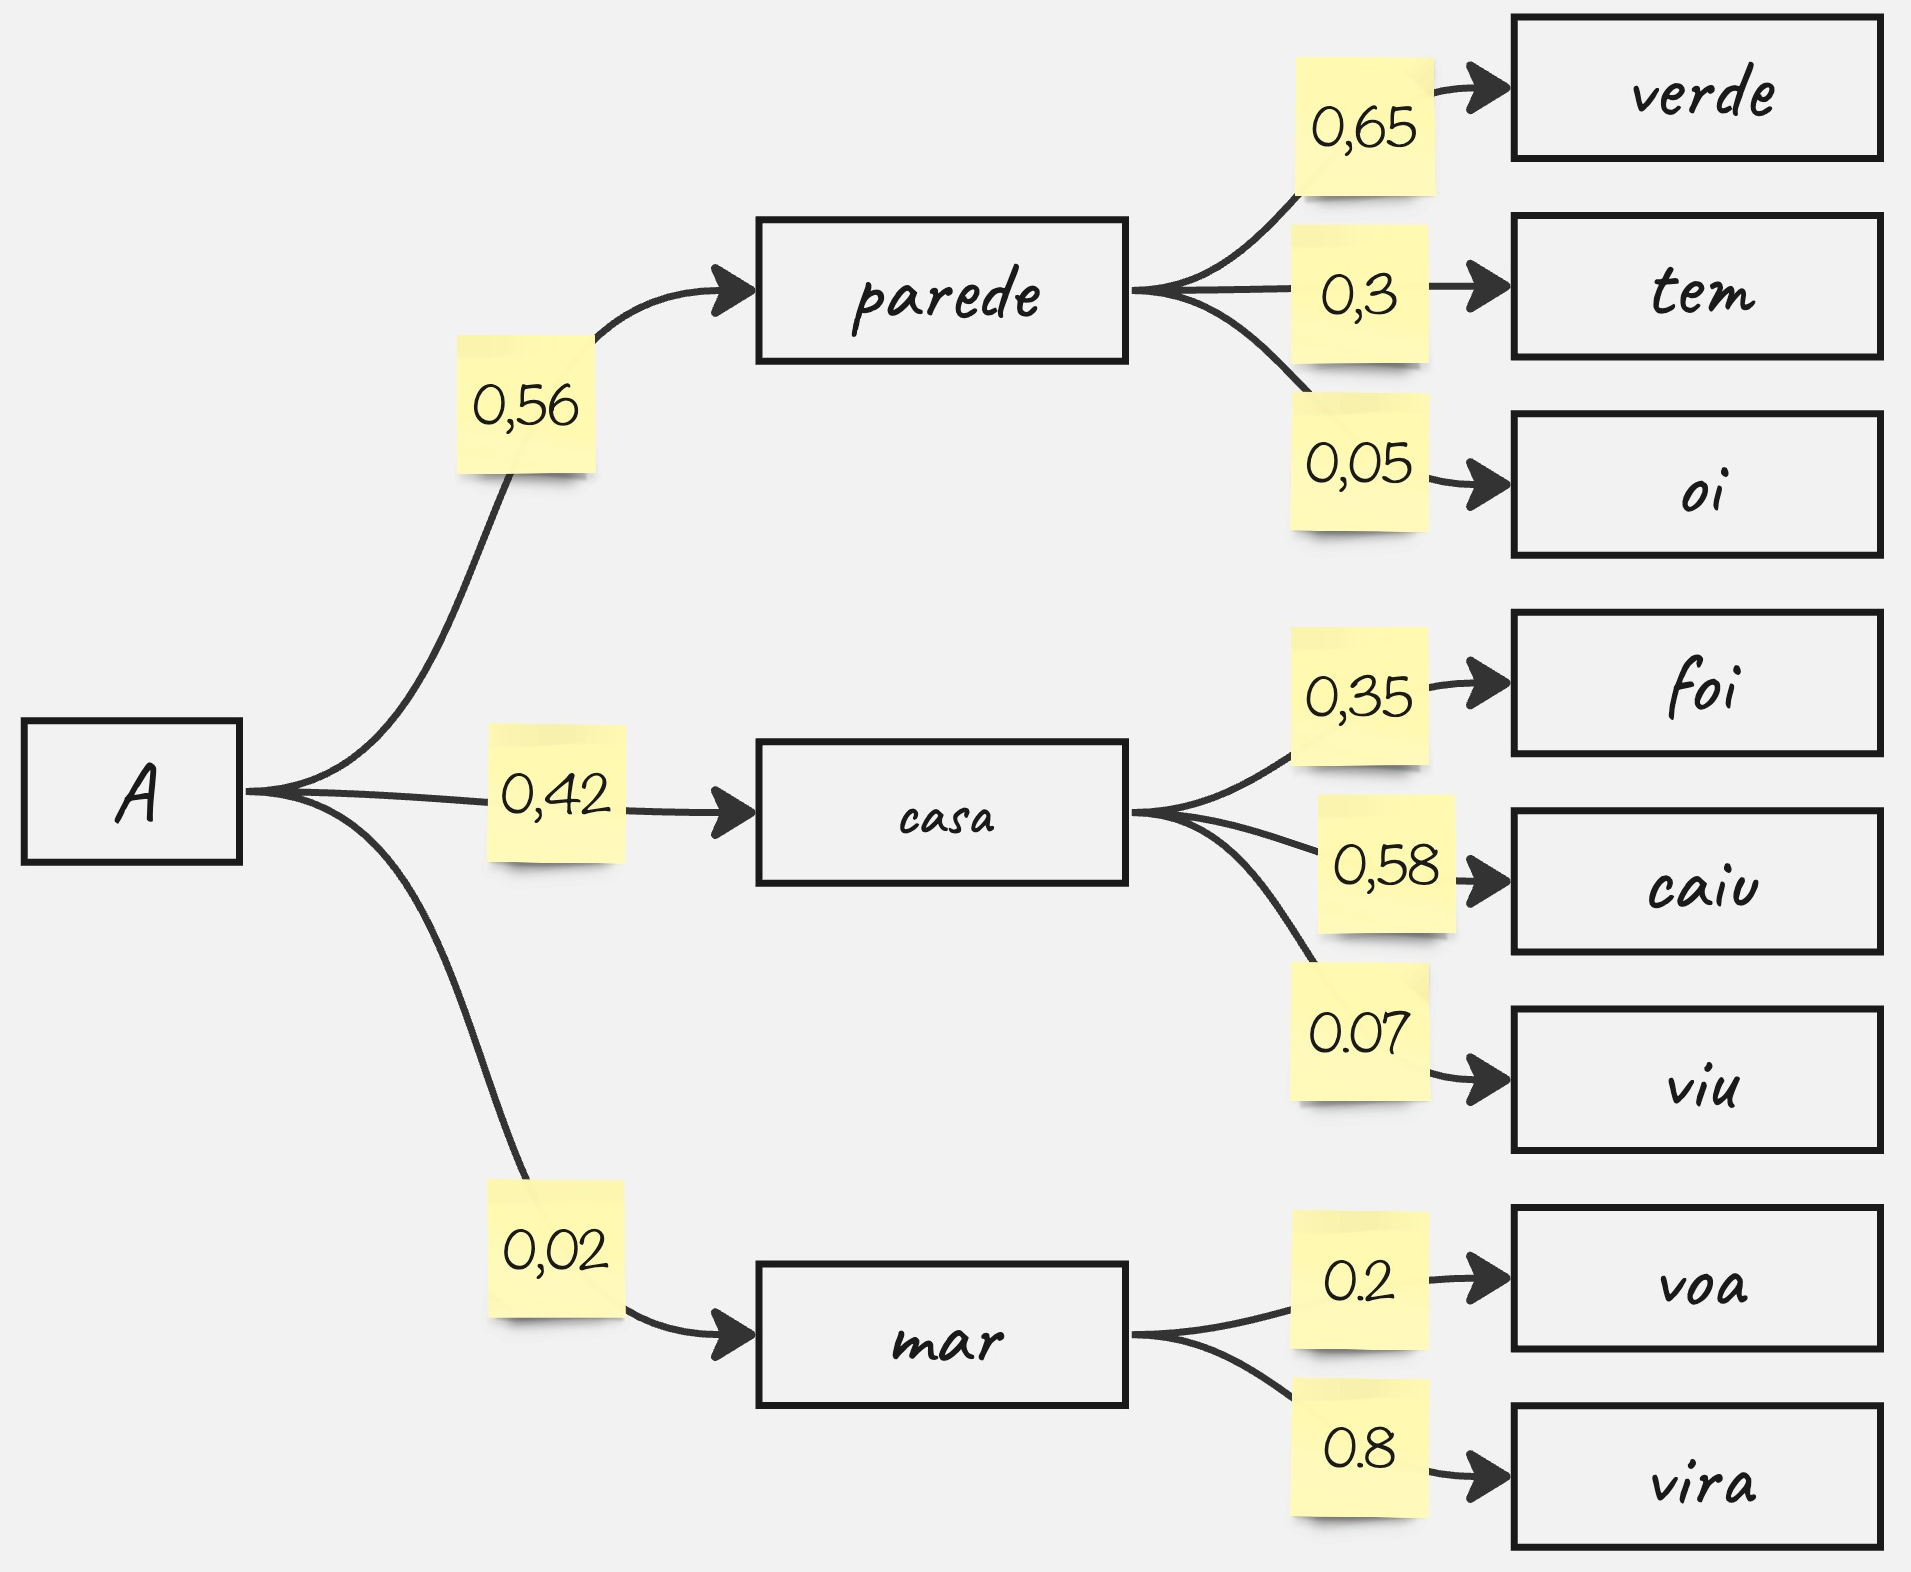

## 1. Classificação de textos com BERTimbau

In [71]:
import os
import sys
import torch
import numpy as np
import datasets.config

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -------------------------------------------------------------------
# Correções de ambiente
# -------------------------------------------------------------------

os.environ["WANDB_DISABLED"] = "true"

# Evita erro do torchvision no Colab em datasets de texto
datasets.config.TORCHVISION_AVAILABLE = False

for module_name in list(sys.modules.keys()):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

# -------------------------------------------------------------------
# Configurações gerais
# -------------------------------------------------------------------

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"  # BERTimbau
BATCH_SIZE = 8
NUM_EPOCHS = 3
MAX_LEN = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# -------------------------------------------------------------------
# Dados de exemplo
# -------------------------------------------------------------------

data = {
    "train": [
        {"text": "O BERT é ótimo para NLP em português!", "label": 0},
        {"text": "Hoje vai chover à tarde.", "label": 1},
        {"text": "Python é uma excelente linguagem.", "label": 2},
    ],
    "validation": [
        {"text": "A previsão do tempo é de sol amanhã.", "label": 1},
        {"text": "Estou aprendendo Machine Learning.", "label": 2},
    ],
}

train_dataset = Dataset.from_list(data["train"])
validation_dataset = Dataset.from_list(data["validation"])

dataset = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset
})

# -------------------------------------------------------------------
# Tokenização
# -------------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Renomeia label para labels, como o Trainer espera
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Remove a coluna textual original
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Aplica formato torch separadamente
train_tokenized = tokenized_datasets["train"].with_format("torch")
validation_tokenized = tokenized_datasets["validation"].with_format("torch")

# -------------------------------------------------------------------
# Modelo
# -------------------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

# -------------------------------------------------------------------
# Argumentos de treinamento
# -------------------------------------------------------------------
# Correção principal:
# evaluation_strategy foi substituído por eval_strategy nesta versão.

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# -------------------------------------------------------------------
# Métricas
# -------------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# -------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    compute_metrics=compute_metrics,
)

# -------------------------------------------------------------------
# Treinamento
# -------------------------------------------------------------------

trainer.train()

# -------------------------------------------------------------------
# Avaliação final
# -------------------------------------------------------------------

metrics = trainer.evaluate()
print("Métricas de avaliação:", metrics)

# -------------------------------------------------------------------
# Predição em novos textos
# -------------------------------------------------------------------

new_texts = [
    "O tempo está ensolarado.",
    "Aprender NLP é muito interessante."
]

new_encodings = tokenizer(
    new_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

new_encodings = {
    key: value.to(device)
    for key, value in new_encodings.items()
}

model.eval()

with torch.no_grad():
    outputs = model(**new_encodings)
    predictions = torch.argmax(outputs.logits, dim=1)

print(f"Predições: {predictions.cpu().numpy()}")

Usando dispositivo: cuda


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Métricas de avaliação: {'eval_loss': 2.0194814205169678, 'eval_accuracy': 0.5, 'eval_precision': 0.25, 'eval_recall': 0.5, 'eval_f1': 0.3333333333333333, 'eval_runtime': 0.0687, 'eval_samples_per_second': 29.113, 'eval_steps_per_second': 14.556, 'epoch': 3.0}
Predições: [1 0]


## 2. NER + BERT para separação, classificação e agrupamento de projetos tecnológicos (DL-2024)

Esta seção implementa o pipeline completo do projeto, usando o dataset **DL-2024** do Kaggle
(`georgekurokijr/dl-2024`), composto por textos de projetos de pesquisa, desenvolvimento e
inovação tecnológica de 2014.

Como **todos** os textos do dataset já pertencem ao domínio de projetos tecnológicos, o
pipeline **não** tenta decidir se um texto é ou não tecnológico. O objetivo é outro:

1. identificar a **área/contexto** de cada projeto;
2. extrair **entidades** relevantes do domínio (área, tecnologia, produto, material, objetivo);
3. gerar **embeddings semânticos** com BERTimbau;
4. **agrupar (clusterizar)** projetos semelhantes combinando NER + BERT;
5. **interpretar** os clusters encontrados.

O fluxo geral é:

1. Carregamento e verificação de encoding (`latin-1`, com testes de fallback);
2. Pré-processamento leve dos textos (sem agressividade, para não prejudicar o BERT);
3. TF-IDF inicial para identificar termos genéricos e construir stopwords do domínio;
4. Definição de entidades do domínio (`AREA`, `TECNOLOGIA`, `PRODUTO_SOLUCAO`,
   `MATERIAL_RECURSO`, `OBJETIVO_PROBLEMA`) com base em dicionários de palavras-chave reais;
5. Geração do `TRAINING_DATA` a partir de uma amostra real do corpus (regras + weak supervision),
   exportado para curadoria manual (`training_data_para_curadoria.csv`);
6. Treinamento de um modelo NER (spaCy) com os dados curados/sugeridos;
7. Extração de entidades em todo o dataset;
8. Geração de embeddings com BERTimbau;
9. Combinação das features de NER com os embeddings do BERT;
10. Clusterização (KMeans, com comparação a DBSCAN/HDBSCAN quando disponível);
11. Visualização com PCA e t-SNE;
12. Interpretação textual de cada cluster;
13. Exportação de todos os resultados em CSV.

> **Sobre a curadoria:** como o dataset não possui anotações manuais de entidades, a estratégia
> adotada é *weak supervision*: um conjunto de regras/dicionários de palavras-chave do domínio
> gera sugestões de entidades a partir dos textos reais. Essas sugestões são exportadas em CSV
> para revisão humana. Se um arquivo revisado for encontrado, ele é usado no treinamento; caso
> contrário, o próprio notebook treina o NER com as sugestões automáticas, deixando claro que,
> nesse caso, o resultado é experimental e depende da qualidade da curadoria posterior.


### 2.1. Carregamento dos dados

In [72]:
# Dependências do pipeline: download do dataset, NLP, BERT, clustering.
!pip -q install kagglehub pandas numpy scikit-learn transformers accelerate spacy matplotlib
# Removido o download do pt_core_news_lg: não é usado (o NER usa spacy.blank("pt")),
# e baixar esse modelo grande só consome tempo à toa.
# HDBSCAN é opcional (comparação com KMeans/DBSCAN). Se a instalação falhar, o notebook
# simplesmente ignora esse algoritmo e segue apenas com KMeans + DBSCAN.
!pip -q install hdbscan || true


In [73]:
import os
import re
import glob
import random
import warnings
from collections import Counter
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import torch

from spacy.training import Example, offsets_to_biluo_tags
from spacy.util import minibatch, compounding, filter_spans
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from transformers import AutoModel, AutoTokenizer

try:
    import hdbscan
    HDBSCAN_DISPONIVEL = True
except ImportError:
    HDBSCAN_DISPONIVEL = False

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Configurações gerais do pipeline
# ---------------------------------------------------------------------
DATASET_SLUG = "georgekurokijr/dl-2024"
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

RANDOM_STATE = 42
MIN_K = 2
MAX_K = 10

# ---------------------------------------------------------------------
# MODO_RAPIDO: liga um conjunto de limites para o notebook rodar em poucos
# minutos (entrega no mesmo dia), em vez de horas. Isso reduz a QUANTIDADE de
# dados processados, mas mantém TODAS as etapas do pipeline (nenhuma é pulada).
# Para rodar com o dataset completo depois, basta trocar para False.
# ---------------------------------------------------------------------
MODO_RAPIDO = True

if MODO_RAPIDO:
    MAX_LEN = 128            # tokens por texto no BERTimbau (era 256)
    BATCH_SIZE = 16          # lotes maiores para gerar embeddings mais rápido
    N_AMOSTRA_TRAINING_DATA = 80    # amostra p/ sugestão de entidades (era 150)
    N_ITER_NER = 20          # iterações de treino do NER (era 60)
    MAX_TEXTOS_DATASET = 800  # limite de textos processados no pipeline inteiro
else:
    MAX_LEN = 256
    BATCH_SIZE = 8
    N_AMOSTRA_TRAINING_DATA = 150
    N_ITER_NER = 60
    MAX_TEXTOS_DATASET = None  # sem limite: usa o dataset completo

# Caminho opcional de um arquivo já curado manualmente. Se existir, ele é usado
# no treinamento do NER no lugar das sugestões automáticas.
CAMINHO_CURADORIA_REVISADA = "training_data_revisado.csv"

# Caminho opcional de um arquivo já curado manualmente. Se existir, ele é usado
# no treinamento do NER no lugar das sugestões automáticas.
CAMINHO_CURADORIA_REVISADA = "training_data_revisado.csv"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
print(f"HDBSCAN disponível: {HDBSCAN_DISPONIVEL}")


Usando dispositivo: cuda
HDBSCAN disponível: True


In [74]:
# Baixar/localizar o dataset do Kaggle.
# No Kaggle, o notebook também funciona apontando diretamente para /kaggle/input,
# caso o dataset já esteja anexado ao notebook.
try:
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
except Exception as exc:
    fallback = "/kaggle/input"
    if os.path.isdir(fallback):
        print("kagglehub falhou, tentando usar /kaggle/input diretamente.")
        dataset_path = fallback
    else:
        raise RuntimeError(
            "Não foi possível localizar o dataset. Verifique se ele está anexado "
            "ao notebook do Kaggle ou se há acesso à internet para o kagglehub."
        ) from exc

print("Dataset localizado em:", dataset_path)

all_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        all_files.append(os.path.join(root, file))

print("Arquivos encontrados:")
for file in all_files:
    print("-", file)


Dataset localizado em: /kaggle/input/datasets/georgekurokijr/dl-2024
Arquivos encontrados:
- /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv


#### Verificação de encoding

O dataset original foi disponibilizado em `latin-1`. Para garantir que o carregamento
não perca ou corrompa caracteres acentuados, o notebook testa explicitamente `latin-1`,
`utf-8`, `utf-8-sig` e `cp1252`, e verifica sinais de texto quebrado (mojibake), como
sequências `Ã`, `Â` ou o caractere de substituição `�`. O encoding escolhido é o que
carrega o arquivo sem erro **e** sem indícios de mojibake nas primeiras linhas.

In [75]:
def contar_sinais_mojibake(texto: str) -> int:
    """Conta ocorrências de padrões típicos de texto mal decodificado."""
    padroes = ["Ã", "Â", "�", "Ã©", "Ã£", "Ã§"]
    return sum(texto.count(p) for p in padroes)


def testar_encodings(file_path: str, encodings=("latin-1", "utf-8", "utf-8-sig", "cp1252")):
    """Testa múltiplos encodings e reporta qual carrega sem erro e com menos mojibake."""
    resultados = []
    for enc in encodings:
        try:
            with open(file_path, "r", encoding=enc) as f:
                amostra = f.read(20000)
            resultados.append({
                "encoding": enc,
                "carregou": True,
                "sinais_mojibake": contar_sinais_mojibake(amostra),
            })
        except (UnicodeDecodeError, UnicodeError) as exc:
            resultados.append({
                "encoding": enc,
                "carregou": False,
                "sinais_mojibake": None,
                "erro": str(exc)[:120],
            })
    return pd.DataFrame(resultados)


def escolher_melhor_encoding(file_path: str, encodings=("latin-1", "utf-8", "utf-8-sig", "cp1252")) -> str:
    """Escolhe o encoding que carrega sem erro e com o menor número de sinais de mojibake.
    Em caso de empate, prioriza latin-1, que é o encoding declarado do dataset.
    """
    diagnostico = testar_encodings(file_path, encodings)
    candidatos = diagnostico[diagnostico["carregou"]].copy()

    if candidatos.empty:
        raise ValueError(f"Nenhum encoding testado conseguiu carregar o arquivo: {file_path}")

    candidatos = candidatos.sort_values("sinais_mojibake", ascending=True)
    melhor = candidatos.iloc[0]["encoding"]

    empatados = candidatos[candidatos["sinais_mojibake"] == candidatos.iloc[0]["sinais_mojibake"]]
    if "latin-1" in empatados["encoding"].values:
        melhor = "latin-1"

    return melhor, diagnostico


# Escolhe o primeiro arquivo tabular suportado dentro do dataset.
supported_extensions = (".csv", ".tsv", ".json", ".jsonl", ".xlsx", ".parquet")
arquivos_tabulares = [
    f for f in glob.glob(os.path.join(dataset_path, "**", "*"), recursive=True)
    if os.path.isfile(f) and f.lower().endswith(supported_extensions)
]

if not arquivos_tabulares:
    raise FileNotFoundError("Nenhum arquivo tabular (CSV/TSV/JSON/JSONL/XLSX/Parquet) foi encontrado.")

arquivo_principal = arquivos_tabulares[0]
print("Arquivo principal:", arquivo_principal)

if arquivo_principal.lower().endswith((".csv", ".tsv")):
    encoding_escolhido, diagnostico_encoding = escolher_melhor_encoding(arquivo_principal)
    print("\nDiagnóstico de encodings testados:")
    display(diagnostico_encoding)
    print("\nEncoding escolhido para leitura:", encoding_escolhido)
else:
    encoding_escolhido = None
    print("Arquivo não é CSV/TSV: verificação de encoding não se aplica diretamente.")


Arquivo principal: /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv

Diagnóstico de encodings testados:


,encoding,carregou,sinais_mojibake,erro
0,latin-1,True,0.0,NaN
1,utf-8,False,NaN,'utf-8' codec can't decode byte 0xed in positi...
2,utf-8-sig,False,NaN,'utf-8' codec can't decode byte 0xed in positi...
3,cp1252,True,0.0,NaN



Encoding escolhido para leitura: latin-1


In [76]:
def carregar_dataset(file_path: str, encoding: str = None) -> pd.DataFrame:
    """Carrega o arquivo tabular do dataset, usando o encoding já diagnosticado
    para CSV/TSV e o leitor apropriado para os demais formatos.
    """
    lower = file_path.lower()

    if lower.endswith(".csv"):
        return pd.read_csv(file_path, encoding=encoding, sep=None, engine="python")
    if lower.endswith(".tsv"):
        return pd.read_csv(file_path, encoding=encoding, sep="\t", engine="python")
    if lower.endswith(".jsonl"):
        return pd.read_json(file_path, lines=True)
    if lower.endswith(".json"):
        return pd.read_json(file_path)
    if lower.endswith(".xlsx"):
        return pd.read_excel(file_path)
    if lower.endswith(".parquet"):
        return pd.read_parquet(file_path)

    raise ValueError(f"Formato não suportado: {file_path}")


df = carregar_dataset(arquivo_principal, encoding=encoding_escolhido)

print("Dimensões do dataset:", df.shape)
print("Colunas:", list(df.columns))
display(df.head())


Dimensões do dataset: (2725, 2)
Colunas: ['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...


#### Identificação automática da coluna de texto

Como o nome das colunas pode variar (acentuação, maiúsculas, underscores), o notebook
normaliza os nomes das colunas e procura por candidatos plausíveis para título e
descrição do projeto. Se nenhum nome conhecido for encontrado, o notebook usa como
fallback as duas primeiras colunas de texto (`object`) do dataframe.

In [77]:
def normalizar_nome_coluna(nome: str) -> str:
    """Remove acentos, espaços e caixa alta para facilitar o casamento de nomes de coluna."""
    return (
        str(nome)
        .strip()
        .lower()
        .replace("ã", "a").replace("á", "a").replace("à", "a").replace("â", "a")
        .replace("é", "e").replace("ê", "e")
        .replace("í", "i")
        .replace("ó", "o").replace("ô", "o").replace("õ", "o")
        .replace("ú", "u")
        .replace("ç", "c")
        .replace(" ", "_")
        .replace("-", "_")
    )


colunas_normalizadas = {normalizar_nome_coluna(col): col for col in df.columns}

CANDIDATOS_TITULO = ["titulo_publico", "titulo", "title", "nome_publico", "projeto", "nome_projeto"]
CANDIDATOS_DESCRICAO = ["descricao_publica", "descricao", "description", "resumo", "abstract"]

COLUNA_TITULO = next((colunas_normalizadas[c] for c in CANDIDATOS_TITULO if c in colunas_normalizadas), None)
COLUNA_DESCRICAO = next((colunas_normalizadas[c] for c in CANDIDATOS_DESCRICAO if c in colunas_normalizadas), None)

# Fallback: usa as duas primeiras colunas textuais do dataframe.
if COLUNA_TITULO is None or COLUNA_DESCRICAO is None:
    colunas_texto = [c for c in df.columns if df[c].dtype == "object"]
    if len(colunas_texto) < 2:
        raise ValueError("Não foi possível identificar duas colunas textuais no dataset.")
    COLUNA_TITULO = COLUNA_TITULO or colunas_texto[0]
    COLUNA_DESCRICAO = COLUNA_DESCRICAO or colunas_texto[1]

print("Coluna de título:", COLUNA_TITULO)
print("Coluna de descrição:", COLUNA_DESCRICAO)


Coluna de título: Título_Público
Coluna de descrição: Descricao_pública


### 2.2. Pré-processamento dos textos

A limpeza aqui é **deliberadamente leve**: remove espaços duplicados e ruídos óbvios de
formatação, mas preserva acentuação e termos técnicos, pois o BERTimbau é sensível ao
texto em português tal como ele aparece naturalmente. Uma limpeza agressiva (remoção de
acentos, stemming, lowercase forçado antes do tokenizer) prejudicaria a qualidade dos
embeddings contextuais. O texto original é mantido em uma coluna separada para
comparação e auditoria.

In [78]:
def limpar_texto(texto: str) -> str:
    """Limpeza leve: normaliza espaços e remove ruídos óbvios, sem tirar acentos."""
    if not isinstance(texto, str):
        return ""

    limpo = texto.strip()
    limpo = re.sub(r"\s+", " ", limpo)              # espaços duplicados/quebras de linha
    limpo = re.sub(r"�", "", limpo)                   # caractere de substituição residual
    limpo = re.sub(r"\.{2,}", ".", limpo)             # sequências de pontos
    limpo = re.sub(r"\s+([,.;:])", r"\1", limpo)      # espaço antes de pontuação
    limpo = limpo.strip()
    return limpo


df_textos = df[[COLUNA_TITULO, COLUNA_DESCRICAO]].copy()
df_textos = df_textos.rename(columns={COLUNA_TITULO: "titulo_original", COLUNA_DESCRICAO: "descricao_original"})

df_textos["titulo_original"] = df_textos["titulo_original"].fillna("").astype(str)
df_textos["descricao_original"] = df_textos["descricao_original"].fillna("").astype(str)

# Texto original (para comparação/auditoria) — apenas concatenação, sem limpeza.
df_textos["texto_original"] = (
    df_textos["titulo_original"].str.strip() + ". " + df_textos["descricao_original"].str.strip()
)

# Texto limpo (usado no restante do pipeline).
df_textos["texto_limpo"] = df_textos["texto_original"].apply(limpar_texto)

df_textos = df_textos[df_textos["texto_limpo"].str.len() > 10].reset_index(drop=True)

# MODO_RAPIDO: limita a quantidade de textos processados no restante do pipeline
# (embeddings, NER, clustering, etc). A amostragem é aleatória e com seed fixa,
# então o resultado é reproduzível. Para usar o dataset completo, defina
# MODO_RAPIDO = False na célula de configuração.
if MAX_TEXTOS_DATASET is not None and len(df_textos) > MAX_TEXTOS_DATASET:
    df_textos = df_textos.sample(n=MAX_TEXTOS_DATASET, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"MODO_RAPIDO ativo: amostra reduzida para {MAX_TEXTOS_DATASET} textos (de um total maior).")

df_textos.insert(0, "id_texto", df_textos.index)

print("Total de textos válidos usados no pipeline:", len(df_textos))
display(df_textos[["id_texto", "texto_original", "texto_limpo"]].head())


MODO_RAPIDO ativo: amostra reduzida para 800 textos (de um total maior).
Total de textos válidos usados no pipeline: 800


,id_texto,texto_original,texto_limpo
0,0,Recuperação de Informação Inteligente e Aprend...,Recuperação de Informação Inteligente e Aprend...
1,1,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...
2,2,Veículo Batedor Autônomo. Desenvolvimento de t...,Veículo Batedor Autônomo. Desenvolvimento de t...
3,3,Desenvolvimento e avaliação operacional de um...,Desenvolvimento e avaliação operacional de um ...
4,4,Seleção de um isolado de Cordyceps (Isaria) sp...,Seleção de um isolado de Cordyceps (Isaria) sp...


### 2.3. Análise TF-IDF inicial

Antes de definir as stopwords customizadas, olhamos para os termos mais relevantes
segundo TF-IDF "cru" (apenas com stopwords gerais do português). Isso ajuda a identificar
quais termos são realmente distintivos de cada projeto e quais são genéricos demais
(por exemplo, "projeto", "desenvolvimento", "tecnologia"), aparecendo em quase todos os
textos e, por isso, atrapalhando tanto o TF-IDF quanto a clusterização.

In [79]:
STOPWORDS_PT_BASE = [
    "a", "o", "as", "os", "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "pelos", "pelas",
    "para", "pra", "com", "sem", "sob", "sobre",
    "entre", "até", "após", "antes", "desde", "contra", "perante",
    "e", "ou", "mas", "porém", "contudo", "todavia",
    "porque", "pois", "que", "se", "quando", "enquanto", "como", "conforme", "embora", "caso",
    "eu", "tu", "ele", "ela", "nós", "vós", "eles", "elas",
    "me", "te", "se", "nos", "vos",
    "meu", "minha", "meus", "minhas", "teu", "tua", "teus", "tuas",
    "seu", "sua", "seus", "suas", "nosso", "nossa", "nossos", "nossas",
    "este", "esta", "estes", "estas", "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas", "isto", "isso", "aquilo",
    "quem", "qual", "quais", "cujo", "cuja", "cujos", "cujas",
    "ser", "estar", "ter", "haver", "fazer", "ir", "vir",
    "foi", "foram", "era", "eram", "são", "é",
    "está", "estão", "estava", "estavam",
    "tem", "têm", "tinha", "tinham", "há", "houve", "havia",
    "faz", "fez", "feito", "vai", "vão", "indo",
    "pode", "podem", "poder", "poderá", "poderão",
    "deve", "devem", "dever", "deverá", "deverão",
    "não", "sim", "também", "ainda", "já", "sempre", "nunca",
    "muito", "muita", "muitos", "muitas", "pouco", "pouca", "poucos", "poucas",
    "mais", "menos", "bem", "mal",
    "aqui", "ali", "lá", "onde", "agora", "depois", "hoje", "ontem", "amanhã",
]

vectorizer_inicial = TfidfVectorizer(
    max_features=5000,
    stop_words=STOPWORDS_PT_BASE,
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents="unicode",
)

tfidf_inicial = vectorizer_inicial.fit_transform(df_textos["texto_limpo"])
termos_iniciais = np.array(vectorizer_inicial.get_feature_names_out())

media_tfidf_inicial = np.asarray(tfidf_inicial.mean(axis=0)).ravel()
ordem_inicial = media_tfidf_inicial.argsort()[::-1]

top_termos_iniciais = pd.DataFrame({
    "termo": termos_iniciais[ordem_inicial[:40]],
    "tfidf_medio": media_tfidf_inicial[ordem_inicial[:40]],
})

print("Termos mais relevantes ANTES de remover ruídos específicos do domínio:")
display(top_termos_iniciais)


Termos mais relevantes ANTES de remover ruídos específicos do domínio:


,termo,tfidf_medio
0,desenvolvimento,0.039376
1,sistema,0.026013
2,projeto,0.025941
3,solucao,0.017730
4,processo,0.017476
5,desenvolver,0.017165
6,producao,0.015854
7,dados,0.014651
8,controle,0.014228
9,objetivo,0.014015


Observando a lista acima, é comum aparecerem termos genéricos que descrevem o **tipo
de documento** (projeto, desenvolvimento, tecnologia, pesquisa, inovação, sistema,
produto, solução, processo, empresa, mercado), e não o **conteúdo** de cada projeto.
Esses termos são adicionados a uma lista de stopwords específica do domínio, usada em
todo o restante do pipeline (TF-IDF final, clusterização e interpretação dos clusters).

In [80]:
STOPWORDS_DOMINIO = [
    "projeto", "projetos",
    "desenvolvimento", "desenvolver", "desenvolvido", "desenvolvida",
    "solução", "soluções",
    "sistema", "sistemas",
    "processo", "processos",
    "produto", "produtos",
    "tecnologia", "tecnologias", "tecnológico", "tecnológica",
    "pesquisa", "pesquisas",
    "inovação", "inovações", "inovador", "inovadora",
    "uso", "utilização", "utilizar", "utilizado", "utilizada",
    "aplicação", "aplicações",
    "método", "métodos", "metodologia",
    "modelo", "modelos",
    "análise", "avaliação",
    "estudo", "estudos",
    "dados", "informações", "informação",
    "empresa", "empresas",
    "mercado", "mercados",
    "área", "áreas",
    "setor", "setores",
    "objetivo", "objetivos",
    "resultado", "resultados",
    "forma", "meio", "parte", "tipo", "nível",
    "atividade", "atividades",
    "trabalho", "trabalhos",
]

STOPWORDS_PT = sorted(set(STOPWORDS_PT_BASE) | set(STOPWORDS_DOMINIO))

vectorizer_final_diag = TfidfVectorizer(
    max_features=5000,
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents="unicode",
)

tfidf_final_diag = vectorizer_final_diag.fit_transform(df_textos["texto_limpo"])
termos_finais_diag = np.array(vectorizer_final_diag.get_feature_names_out())

media_tfidf_final_diag = np.asarray(tfidf_final_diag.mean(axis=0)).ravel()
ordem_final_diag = media_tfidf_final_diag.argsort()[::-1]

top_termos_finais_diag = pd.DataFrame({
    "termo": termos_finais_diag[ordem_final_diag[:40]],
    "tfidf_medio": media_tfidf_final_diag[ordem_final_diag[:40]],
})

print("Termos mais relevantes DEPOIS de remover stopwords do domínio:")
display(top_termos_finais_diag)

comparacao_stopwords = pd.DataFrame({
    "antes_da_remocao": top_termos_iniciais["termo"].head(20).tolist(),
    "depois_da_remocao": top_termos_finais_diag["termo"].head(20).tolist(),
})
print("\nComparação lado a lado (top 20):")
display(comparacao_stopwords)


Termos mais relevantes DEPOIS de remover stopwords do domínio:


,termo,tfidf_medio
0,solucao,0.019274
1,producao,0.017094
2,controle,0.015637
3,software,0.014667
4,aplicacao,0.014171
5,plataforma,0.013934
6,monitoramento,0.013001
7,inteligente,0.011962
8,ao,0.011649
9,prototipo,0.011537



Comparação lado a lado (top 20):


,antes_da_remocao,depois_da_remocao
0,desenvolvimento,solucao
1,sistema,producao
2,projeto,controle
3,solucao,software
4,processo,aplicacao
5,desenvolver,plataforma
6,producao,monitoramento
7,dados,inteligente
8,controle,ao
9,objetivo,prototipo


### 2.4. Criação das entidades de NER

As entidades foram desenhadas especificamente para o domínio de projetos de C,T&I
(Ciência, Tecnologia e Inovação), com base em vocabulário real observado nesse tipo de
texto — e não em exemplos artificiais de outro domínio (como manufatura aditiva):

* **`AREA`** — área/setor do projeto (saúde, educação, energia, agricultura, indústria,
  transporte, meio ambiente, biotecnologia, software, automação, segurança, comunicação,
  materiais, alimentos etc.);
* **`TECNOLOGIA`** — tecnologias, métodos ou ferramentas (inteligência artificial,
  sensores, software, aplicativo, plataforma, algoritmo, automação, robótica,
  nanotecnologia, sistemas embarcados, internet das coisas etc.);
* **`PRODUTO_SOLUCAO`** — produto, solução, sistema, equipamento, plataforma, dispositivo,
  protótipo ou serviço desenvolvido;
* **`MATERIAL_RECURSO`** — materiais, insumos ou recursos técnicos/físicos usados;
* **`OBJETIVO_PROBLEMA`** — problema, finalidade ou objetivo do projeto (reduzir custos,
  melhorar eficiência, monitorar processos, aumentar segurança, tratar doença etc.).

Os dicionários abaixo são usados tanto para gerar sugestões automáticas de entidades
(weak supervision) quanto, mais adiante, como uma checagem de sanidade para as entidades
extraídas pelo modelo treinado.

In [81]:
# Dicionários de palavras-chave por tipo de entidade. As entradas com mais de uma
# palavra são tratadas como expressões (casamento de frase completa).
ENTIDADES_DOMINIO = {
    "AREA": [
        "saúde", "educação", "energia", "agricultura", "agropecuária", "indústria",
        "transporte", "meio ambiente", "ambiental", "biotecnologia", "software",
        "automação", "segurança", "comunicação", "telecomunicações", "materiais",
        "alimentos", "agroindústria", "construção civil", "mineração", "petróleo",
        "gás natural", "química", "farmacêutica", "veterinária", "aeroespacial",
        "naval", "mecânica", "eletrônica", "metalurgia", "têxtil", "logística",
        "biomedicina", "nanotecnologia", "geociências", "oceanografia",
    ],
    "TECNOLOGIA": [
        "inteligência artificial", "sensor", "sensores", "software", "aplicativo",
        "plataforma digital", "algoritmo", "automação", "robótica", "nanotecnologia",
        "biotecnologia", "sistemas embarcados", "internet das coisas", "big data",
        "aprendizado de máquina", "visão computacional", "realidade aumentada",
        "realidade virtual", "computação em nuvem", "drone", "drones",
        "impressão 3d", "manufatura aditiva", "cnc", "controlador lógico programável",
        "telemetria", "geolocalização", "gps", "rfid", "bluetooth", "wireless",
        "criptografia", "biometria", "processamento de imagens", "banco de dados",
    ],
    "PRODUTO_SOLUCAO": [
        "protótipo", "dispositivo", "equipamento", "plataforma", "aplicativo",
        "software", "máquina", "ferramenta", "kit", "componente", "módulo",
        "sistema de", "solução para", "produto", "serviço",
    ],
    "MATERIAL_RECURSO": [
        "matéria-prima", "polímero", "metal", "liga metálica", "compósito",
        "biomassa", "resíduo", "resíduos", "energia solar", "energia elétrica",
        "água", "solo", "fibra", "cerâmica", "insumo", "insumos", "reagente",
        "catalisador", "biomaterial", "nanomaterial",
    ],
    "OBJETIVO_PROBLEMA": [
        "reduzir custo", "reduzir custos", "melhorar eficiência", "melhorar a eficiência",
        "monitorar", "monitoramento", "otimizar produção", "otimizar a produção",
        "aumentar segurança", "aumentar a segurança", "tratar doença", "tratar doenças",
        "melhorar diagnóstico", "melhorar o diagnóstico", "diminuir custos",
        "diminuir o consumo", "prevenir", "controlar", "detectar", "identificar",
        "automatizar processos", "reduzir impacto ambiental", "aumentar produtividade",
        "melhorar qualidade", "melhorar a qualidade", "reduzir desperdício",
    ],
}

# Ordena cada lista da mais longa para a mais curta, para casar expressões maiores
# antes de expressões menores (evita, por exemplo, casar só "energia" quando o texto
# tem "energia solar").
for tipo in ENTIDADES_DOMINIO:
    ENTIDADES_DOMINIO[tipo] = sorted(ENTIDADES_DOMINIO[tipo], key=len, reverse=True)

print("Quantidade de expressões por tipo de entidade:")
for tipo, termos in ENTIDADES_DOMINIO.items():
    print(f"- {tipo}: {len(termos)} expressões")


Quantidade de expressões por tipo de entidade:
- AREA: 36 expressões
- TECNOLOGIA: 35 expressões
- PRODUTO_SOLUCAO: 15 expressões
- MATERIAL_RECURSO: 20 expressões
- OBJETIVO_PROBLEMA: 26 expressões


In [82]:
def encontrar_entidades_por_regra(texto: str) -> list:
    """Varre o texto em busca de expressões dos dicionários de domínio.
    Retorna uma lista de tuplas (start, end, label), sem sobreposição:
    entidades mais longas têm prioridade sobre entidades mais curtas que se sobrepõem.
    """
    texto_lower = texto.lower()
    candidatas = []

    for tipo, expressoes in ENTIDADES_DOMINIO.items():
        for expressao in expressoes:
            padrao = r"\b" + re.escape(expressao) + r"\b"
            for match in re.finditer(padrao, texto_lower):
                candidatas.append((match.start(), match.end(), tipo))

    # Ordena por tamanho decrescente para priorizar expressões mais longas/específicas.
    candidatas.sort(key=lambda item: (item[1] - item[0]), reverse=True)

    selecionadas = []
    ocupado = np.zeros(len(texto), dtype=bool)

    for start, end, label in candidatas:
        if not ocupado[start:end].any():
            selecionadas.append((start, end, label))
            ocupado[start:end] = True

    selecionadas.sort(key=lambda item: item[0])
    return selecionadas


# Teste rápido de sanidade em alguns textos reais do dataset.
for texto_teste in df_textos["texto_limpo"].head(3):
    entidades = encontrar_entidades_por_regra(texto_teste)
    print("TEXTO:", texto_teste[:200])
    print("ENTIDADES:", [(texto_teste[s:e], label) for s, e, label in entidades])
    print("-" * 100)


TEXTO: Recuperação de Informação Inteligente e Aprendizado de Máquina Aplicados a E-Commerce (RecInt-eComm). Criação e implementação de soluções para melhorias dos serviços de informação tanto do lado do usu
ENTIDADES: [('Aprendizado de Máquina', 'TECNOLOGIA'), ('produto', 'PRODUTO_SOLUCAO')]
----------------------------------------------------------------------------------------------------
TEXTO: DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL PARA EQUIPAMENTOS SUBMARINOS - PROJETO GEMEOSS. Desenvolvimento de um gêmeo digital de equipamentos submarinos para apoio decisão em extensão de vida, re
ENTIDADES: []
----------------------------------------------------------------------------------------------------
TEXTO: Veículo Batedor Autônomo. Desenvolvimento de tecnologias e fusão de sensores para condução autônoma e inspeção da condição operacional de vias férreas após condição climática severa.
ENTIDADES: [('sensores', 'TECNOLOGIA')]
----------------------------------------------------

### 2.5. Construção do `TRAINING_DATA` a partir de textos reais

Diferente da versão anterior deste notebook — que usava frases artificiais sobre
impressão 3D, fora do domínio do dataset —, o `TRAINING_DATA` aqui é construído
**exclusivamente a partir de uma amostra dos textos reais** de projetos de C,T&I.

A estratégia é:

1. amostrar `N_AMOSTRA_TRAINING_DATA` textos reais do dataset;
2. aplicar as regras de palavras-chave (`encontrar_entidades_por_regra`) como
   **weak supervision** — uma primeira sugestão automática de entidades;
3. exportar essas sugestões, junto com o texto original e o texto limpo, em
   `training_data_para_curadoria.csv`, com colunas para validação manual e observações;
4. permitir carregar de volta um arquivo revisado manualmente
   (`training_data_revisado.csv`) e usá-lo no treinamento, se ele existir.

Se nenhum arquivo revisado for encontrado, o notebook segue com as sugestões
automáticas, deixando claro que, nesse caso, o modelo de NER treinado é **experimental**.

In [83]:
# Amostra real de textos para gerar sugestões de entidades.
amostra_training = df_textos.sample(
    n=min(N_AMOSTRA_TRAINING_DATA, len(df_textos)),
    random_state=RANDOM_STATE,
).reset_index(drop=True)

linhas_curadoria = []

for _, linha in amostra_training.iterrows():
    texto_original = linha["texto_original"]
    texto_limpo = linha["texto_limpo"]
    entidades = encontrar_entidades_por_regra(texto_limpo)

    if not entidades:
        # Mantém uma linha "vazia" para o texto aparecer na planilha de curadoria
        # mesmo quando nenhuma entidade foi sugerida automaticamente.
        linhas_curadoria.append({
            "id_texto": linha["id_texto"],
            "texto_original": texto_original,
            "texto_limpo": texto_limpo,
            "entidade_sugerida": "",
            "tipo_entidade_sugerida": "",
            "posicao_inicial": "",
            "posicao_final": "",
            "validado_manualmente": "",
            "observacoes": "",
        })
        continue

    for start, end, label in entidades:
        linhas_curadoria.append({
            "id_texto": linha["id_texto"],
            "texto_original": texto_original,
            "texto_limpo": texto_limpo,
            "entidade_sugerida": texto_limpo[start:end],
            "tipo_entidade_sugerida": label,
            "posicao_inicial": start,
            "posicao_final": end,
            "validado_manualmente": "",   # preencher com SIM/NAO na curadoria
            "observacoes": "",
        })

df_training_curadoria = pd.DataFrame(linhas_curadoria)

print("Total de linhas geradas para curadoria:", len(df_training_curadoria))
display(df_training_curadoria.head(15))

df_training_curadoria.to_csv("training_data_para_curadoria.csv", index=False, encoding="latin-1")
print("\nArquivo gerado: training_data_para_curadoria.csv")


Total de linhas geradas para curadoria: 186


,id_texto,texto_original,texto_limpo,entidade_sugerida,tipo_entidade_sugerida,posicao_inicial,posicao_final,validado_manualmente,observacoes
0,696,Desenvolvimento de nova resina. Desenvolviment...,Desenvolvimento de nova resina. Desenvolviment...,,,,,,
1,667,Sistema de Autodiagnóstico para Sensores de Te...,Sistema de Autodiagnóstico para Sensores de Te...,Sistema de,PRODUTO_SOLUCAO,0,10,,
2,667,Sistema de Autodiagnóstico para Sensores de Te...,Sistema de Autodiagnóstico para Sensores de Te...,Sensores,TECNOLOGIA,32,40,,
3,63,Desenvolvimento de Eletrônica para Válvula de ...,Desenvolvimento de Eletrônica para Válvula de ...,Eletrônica,AREA,19,29,,
4,63,Desenvolvimento de Eletrônica para Válvula de ...,Desenvolvimento de Eletrônica para Válvula de ...,ELETRÔNICA,AREA,117,127,,
5,63,Desenvolvimento de Eletrônica para Válvula de ...,Desenvolvimento de Eletrônica para Válvula de ...,Eletrônica,AREA,162,172,,
6,533,Shadow Bright. O projeto tem como objetivo a o...,Shadow Bright. O projeto tem como objetivo a o...,automação,AREA,658,667,,
7,66,Desenvolvimento do processo de manufatura para...,Desenvolvimento do processo de manufatura para...,,,,,,
8,621,Desenvolvimento e validação de aerogel de graf...,Desenvolvimento e validação de aerogel de graf...,,,,,,
9,346,ARIC. Plataforma de software para Análise de R...,ARIC. Plataforma de software para Análise de R...,Plataforma,PRODUTO_SOLUCAO,6,16,,



Arquivo gerado: training_data_para_curadoria.csv


#### Curadoria

Depois de exportado, o arquivo `training_data_para_curadoria.csv` pode ser aberto em uma
planilha e revisado manualmente: preenchendo `validado_manualmente` com `SIM`/`NAO` e,
se necessário, corrigindo `tipo_entidade_sugerida` ou as posições. Ao salvar o arquivo
revisado como `training_data_revisado.csv` (mesmas colunas) no diretório de trabalho, o
notebook passa a usá-lo automaticamente no treinamento do NER.

In [84]:
def montar_training_data(df_anotacoes: pd.DataFrame, exigir_validado: bool = False) -> list:
    """Converte um dataframe de anotações (sugerido ou curado) para o formato
    de treinamento do spaCy: lista de (texto, {"entities": [(start, end, label), ...]}).
    """
    training_data = []

    for id_texto, grupo in df_anotacoes.groupby("id_texto"):
        texto_limpo = grupo["texto_limpo"].iloc[0]
        entidades = []

        for _, linha in grupo.iterrows():
            if not linha.get("tipo_entidade_sugerida"):
                continue
            if exigir_validado and str(linha.get("validado_manualmente", "")).strip().upper() != "SIM":
                continue

            try:
                start = int(linha["posicao_inicial"])
                end = int(linha["posicao_final"])
            except (ValueError, TypeError):
                continue

            entidades.append((start, end, linha["tipo_entidade_sugerida"]))

        if entidades:
            training_data.append((texto_limpo, {"entities": entidades}))

    return training_data


if os.path.exists(CAMINHO_CURADORIA_REVISADA):
    print(f"Arquivo curado encontrado: {CAMINHO_CURADORIA_REVISADA}. Usando curadoria manual.")
    df_curado = pd.read_csv(CAMINHO_CURADORIA_REVISADA, encoding="latin-1")
    TRAINING_DATA_BRUTO = montar_training_data(df_curado, exigir_validado=True)
    TREINO_EXPERIMENTAL = False
else:
    print(
        "Nenhum arquivo de curadoria manual encontrado "
        f"({CAMINHO_CURADORIA_REVISADA}). Usando sugestões automáticas (weak supervision)."
    )
    TRAINING_DATA_BRUTO = montar_training_data(df_training_curadoria, exigir_validado=False)
    TREINO_EXPERIMENTAL = True

print("Total de exemplos de treino (antes da validação de offsets):", len(TRAINING_DATA_BRUTO))
if TREINO_EXPERIMENTAL:
    print(
        "\nAVISO: o treinamento do NER abaixo é EXPERIMENTAL, pois usa apenas as "
        "sugestões automáticas de weak supervision. Para um resultado mais confiável, "
        "revise manualmente 'training_data_para_curadoria.csv' e salve como "
        f"'{CAMINHO_CURADORIA_REVISADA}'."
    )


Nenhum arquivo de curadoria manual encontrado (training_data_revisado.csv). Usando sugestões automáticas (weak supervision).
Total de exemplos de treino (antes da validação de offsets): 68

AVISO: o treinamento do NER abaixo é EXPERIMENTAL, pois usa apenas as sugestões automáticas de weak supervision. Para um resultado mais confiável, revise manualmente 'training_data_para_curadoria.csv' e salve como 'training_data_revisado.csv'.


### 2.6. Treinamento do modelo de NER

In [85]:
# Pipeline spaCy limpo para português, específico para este NER de domínio.
nlp_ner = spacy.blank("pt")
ner = nlp_ner.add_pipe("ner")

for _, annotations in TRAINING_DATA_BRUTO:
    for _, _, label in annotations.get("entities", []):
        ner.add_label(label)

print("Labels cadastrados no NER:", ner.labels)


def exemplo_valido(nlp, texto, annotations):
    """Valida se as entidades anotadas se alinham com a tokenização do spaCy."""
    doc = nlp.make_doc(texto)
    entidades = annotations.get("entities", [])
    try:
        tags = offsets_to_biluo_tags(doc, entidades)
    except Exception:
        return False
    return "-" not in tags


TRAINING_DATA_VALIDO = [
    (texto, annotations)
    for texto, annotations in TRAINING_DATA_BRUTO
    if exemplo_valido(nlp_ner, texto, annotations)
]

print(f"Exemplos originais: {len(TRAINING_DATA_BRUTO)}")
print(f"Exemplos válidos (offsets alinhados à tokenização): {len(TRAINING_DATA_VALIDO)}")

if len(TRAINING_DATA_VALIDO) < 5:
    raise ValueError(
        "Poucos exemplos válidos para treinar o NER. Aumente N_AMOSTRA_TRAINING_DATA "
        "ou revise a curadoria manual."
    )

# Separação treino/validação para evitar avaliar o modelo nos mesmos exemplos usados
# no treinamento.
random.Random(RANDOM_STATE).shuffle(TRAINING_DATA_VALIDO)
corte = max(1, int(0.85 * len(TRAINING_DATA_VALIDO)))
TRAINING_DATA_TREINO = TRAINING_DATA_VALIDO[:corte]
TRAINING_DATA_VAL = TRAINING_DATA_VALIDO[corte:]

print(f"Treino: {len(TRAINING_DATA_TREINO)} exemplos | Validação: {len(TRAINING_DATA_VAL)} exemplos")


Labels cadastrados no NER: ('AREA', 'MATERIAL_RECURSO', 'OBJETIVO_PROBLEMA', 'PRODUTO_SOLUCAO', 'TECNOLOGIA')
Exemplos originais: 68
Exemplos válidos (offsets alinhados à tokenização): 66
Treino: 56 exemplos | Validação: 10 exemplos


Iteração 0 - Loss NER: 2597.9456
Iteração 10 - Loss NER: 106.4956
Iteração 19 - Loss NER: 24.4135

Modelo salvo em: custom_ner_model


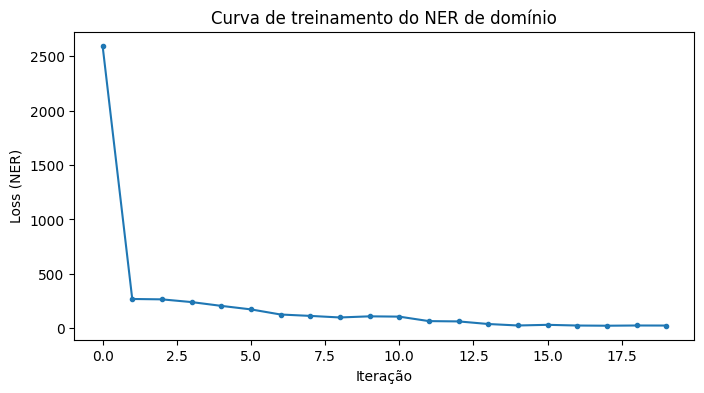

In [86]:
def montar_exemplos(nlp, dados):
    exemplos = []
    for texto, annotations in dados:
        doc = nlp.make_doc(texto)
        exemplos.append(Example.from_dict(doc, annotations))
    return exemplos


exemplos_iniciais = montar_exemplos(nlp_ner, TRAINING_DATA_TREINO)
optimizer = nlp_ner.initialize(lambda: exemplos_iniciais)

N_ITER = N_ITER_NER  # controlado por MODO_RAPIDO na célula de configuração
historico_perdas = []

for iteracao in range(N_ITER):
    random.shuffle(TRAINING_DATA_TREINO)
    losses = {}

    batches = minibatch(TRAINING_DATA_TREINO, size=compounding(4.0, 32.0, 1.001))
    for batch in batches:
        exemplos_batch = montar_exemplos(nlp_ner, batch)
        nlp_ner.update(exemplos_batch, sgd=optimizer, drop=0.35, losses=losses)

    perda_ner = losses.get("ner", 0.0)
    historico_perdas.append(perda_ner)
    if iteracao % 10 == 0 or iteracao == N_ITER - 1:
        print(f"Iteração {iteracao} - Loss NER: {perda_ner:.4f}")

    if perda_ner < 0.01:
        print(f"Early stopping na iteração {iteracao}")
        break

nlp_ner.to_disk("custom_ner_model")
print("\nModelo salvo em: custom_ner_model")

plt.figure(figsize=(8, 4))
plt.plot(historico_perdas, marker="o", markersize=3)
plt.xlabel("Iteração")
plt.ylabel("Loss (NER)")
plt.title("Curva de treinamento do NER de domínio")
plt.show()


#### Avaliação qualitativa do NER

Como o conjunto de dados é pequeno e baseado em weak supervision (ou em curadoria
manual de escopo limitado), a avaliação aqui é primariamente **qualitativa**: inspecionar
as entidades extraídas em exemplos de validação e no restante do corpus.

In [87]:
nlp_ner_treinado = spacy.load("custom_ner_model")

print("Exemplos do conjunto de VALIDAÇÃO (não usados no treino):\n")
for texto, anotacoes_esperadas in TRAINING_DATA_VAL[:5]:
    doc = nlp_ner_treinado(texto)
    entidades_esperadas = [(texto[s:e], label) for s, e, label in anotacoes_esperadas["entities"]]
    entidades_previstas = [(ent.text, ent.label_) for ent in doc.ents]

    print("TEXTO:", texto[:300])
    print("ESPERADO :", entidades_esperadas)
    print("PREVISTO :", entidades_previstas)
    print("-" * 100)


Exemplos do conjunto de VALIDAÇÃO (não usados no treino):

TEXTO: Sistema de Autodiagnóstico para Sensores de Temperatura e Pressão - EMBEDDO. O projeto visa melhorar o hardware para o autodiagnostico e autoajuste baseado em medições redundantes na linha de produção e um modelo preditivo embarcado. Permitindo assim, o espaçamento entre as calibrações em bancada e 
ESPERADO : [('Sistema de', 'PRODUTO_SOLUCAO'), ('Sensores', 'TECNOLOGIA')]
PREVISTO : [('Sistema de', 'PRODUTO_SOLUCAO'), ('Sensores', 'TECNOLOGIA')]
----------------------------------------------------------------------------------------------------
TEXTO: Rover para Café. Desenvolver um sistema robotizado para revolvimento de café por meio de sistemas inteligentes e de orientação que atenda a necessidade do produtor, o sistema deve ser de fácil acionamento e condução, fácil acompanhamento e capacidade de revolvimento do café. O projeto deve atender a
ESPERADO : [('energia elétrica', 'MATERIAL_RECURSO'), ('energia solar', 'M

### 2.7. Extração de entidades em todo o dataset

In [88]:
registros_entidades = []

for _, linha in df_textos.iterrows():
    doc = nlp_ner_treinado(linha["texto_limpo"])
    for ent in doc.ents:
        registros_entidades.append({
            "id_texto": linha["id_texto"],
            "texto": linha["texto_limpo"],
            "entidade": ent.text,
            "tipo_entidade": ent.label_,
            "posicao_inicial": ent.start_char,
            "posicao_final": ent.end_char,
        })

df_entidades = pd.DataFrame(registros_entidades)

print("Total de entidades extraídas:", len(df_entidades))
if len(df_entidades) > 0:
    display(df_entidades["tipo_entidade"].value_counts().rename_axis("tipo_entidade").reset_index(name="quantidade"))
    display(df_entidades.head(15))
else:
    print(
        "Nenhuma entidade foi extraída pelo modelo treinado. Isso pode acontecer com "
        "conjuntos de treino muito pequenos/experimentais - revise a curadoria manual."
    )

df_entidades.to_csv("entidades_extraidas_ner.csv", index=False, encoding="latin-1")
print("\nArquivo gerado: entidades_extraidas_ner.csv")


Total de entidades extraídas: 1562


,tipo_entidade,quantidade
0,AREA,613
1,PRODUTO_SOLUCAO,592
2,OBJETIVO_PROBLEMA,150
3,TECNOLOGIA,124
4,MATERIAL_RECURSO,83


,id_texto,texto,entidade,tipo_entidade,posicao_inicial,posicao_final
0,0,Recuperação de Informação Inteligente e Aprend...,Máquina,PRODUTO_SOLUCAO,55,62
1,1,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,apoio,AREA,163,168
2,2,Veículo Batedor Autônomo. Desenvolvimento de t...,sensores,TECNOLOGIA,68,76
3,3,Desenvolvimento e avaliação operacional de um ...,sistema de,PRODUTO_SOLUCAO,106,116
4,3,Desenvolvimento e avaliação operacional de um ...,compósito,MATERIAL_RECURSO,152,161
5,3,Desenvolvimento e avaliação operacional de um ...,sistema de,PRODUTO_SOLUCAO,295,305
6,3,Desenvolvimento e avaliação operacional de um ...,compósito,MATERIAL_RECURSO,341,350
7,5,Viabilidade de aproveitamento de rejeitos de m...,agricultura,AREA,76,87
8,5,Viabilidade de aproveitamento de rejeitos de m...,produto,PRODUTO_SOLUCAO,104,111
9,6,AGUARDANDO AUTORIZAÇÃO CLIENTE - Subsistema do...,Subsistema do,PRODUTO_SOLUCAO,33,46



Arquivo gerado: entidades_extraidas_ner.csv


### 2.8. Geração de embeddings com BERTimbau

In [89]:
# BERTimbau é usado para capturar o contexto semântico dos projetos, complementando
# as entidades estruturadas extraídas pelo NER. Usamos mean pooling sobre os tokens,
# respeitando a attention_mask, para obter um vetor por texto.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bertimbau = AutoModel.from_pretrained(MODEL_NAME).to(device)
bertimbau.eval()


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    somado = torch.sum(last_hidden_state * mask, dim=1)
    contagem = torch.clamp(mask.sum(dim=1), min=1e-9)
    return somado / contagem


def gerar_embeddings(textos, batch_size=BATCH_SIZE):
    """Gera embeddings para uma lista de textos, truncando textos longos em MAX_LEN
    tokens. Para este dataset (textos curtos/médios de projetos), o truncamento simples
    é suficiente; para textos muito longos, uma estratégia de blocos com agregação
    (ex.: média dos blocos) seria necessária.
    """
    embeddings = []
    for inicio in range(0, len(textos), batch_size):
        lote = textos[inicio:inicio + batch_size]
        tokens = tokenizer(
            lote,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}

        with torch.no_grad():
            saida = bertimbau(**tokens)
            emb_lote = mean_pooling(saida.last_hidden_state, tokens["attention_mask"])

        embeddings.append(emb_lote.cpu().numpy())

    return np.vstack(embeddings)


embeddings_bert = gerar_embeddings(df_textos["texto_limpo"].tolist())
print("Formato dos embeddings BERTimbau:", embeddings_bert.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Formato dos embeddings BERTimbau: (800, 768)


### 2.9. Combinação entre NER e BERT

Os embeddings do BERTimbau capturam o significado geral do texto, mas não deixam
explícito **quais** entidades (área, tecnologia, produto, material, objetivo) aparecem em
cada projeto. Para reforçar essa informação estruturada na etapa de clusterização,
construímos features adicionais a partir das entidades extraídas — contagens por tipo de
entidade e presença/ausência das áreas e tecnologias mais frequentes — e as concatenamos
(depois de padronizadas) aos embeddings do BERT.

In [90]:
TIPOS_ENTIDADE = list(ENTIDADES_DOMINIO.keys())

# Contagem de entidades por tipo, por texto.
contagem_por_tipo = (
    df_entidades.groupby(["id_texto", "tipo_entidade"]).size().unstack(fill_value=0)
    if len(df_entidades) > 0
    else pd.DataFrame(index=df_textos["id_texto"])
)
contagem_por_tipo = contagem_por_tipo.reindex(columns=TIPOS_ENTIDADE, fill_value=0)
contagem_por_tipo = contagem_por_tipo.reindex(df_textos["id_texto"], fill_value=0)
contagem_por_tipo.columns = [f"qtd_{c.lower()}" for c in contagem_por_tipo.columns]

# Área e tecnologia mais frequentes por texto, para leitura humana no relatório final.
def entidade_mais_frequente(id_texto, tipo):
    if len(df_entidades) == 0:
        return ""
    subset = df_entidades[(df_entidades["id_texto"] == id_texto) & (df_entidades["tipo_entidade"] == tipo)]
    if subset.empty:
        return ""
    return Counter(subset["entidade"].str.lower()).most_common(1)[0][0]


df_textos["area_sugerida"] = df_textos["id_texto"].apply(lambda i: entidade_mais_frequente(i, "AREA"))
df_textos["tecnologias_identificadas"] = df_textos["id_texto"].apply(
    lambda i: "; ".join(sorted(set(
        df_entidades[(df_entidades["id_texto"] == i) & (df_entidades["tipo_entidade"] == "TECNOLOGIA")]["entidade"].str.lower()
    ))) if len(df_entidades) > 0 else ""
)
df_textos["entidades_identificadas"] = df_textos["id_texto"].apply(
    lambda i: "; ".join(
        f"{row.entidade} ({row.tipo_entidade})"
        for row in df_entidades[df_entidades["id_texto"] == i].itertuples()
    ) if len(df_entidades) > 0 else ""
)

# Padroniza as features de entidade (contagens) antes de combinar com o BERT, já que
# estão em escalas muito diferentes (contagens pequenas vs. embeddings contínuos).
scaler_entidades = StandardScaler()
features_entidades = scaler_entidades.fit_transform(contagem_por_tipo.values.astype(float))

# Combina embeddings do BERT com as features estruturadas de NER.
# Um peso pequeno é aplicado às features de NER para que elas reforcem, sem dominar,
# a geometria já definida pelos embeddings semânticos do BERT.
PESO_FEATURES_NER = 0.5
features_combinadas = np.hstack([embeddings_bert, features_entidades * PESO_FEATURES_NER])

print("Formato dos embeddings BERT:", embeddings_bert.shape)
print("Formato das features de NER:", features_entidades.shape)
print("Formato das features combinadas (BERT + NER):", features_combinadas.shape)


Formato dos embeddings BERT: (800, 768)
Formato das features de NER: (800, 5)
Formato das features combinadas (BERT + NER): (800, 773)


### 2.10. Clusterização dos textos

A clusterização é feita sobre as features combinadas (BERT + NER). Testamos KMeans
para um intervalo de `k`, escolhendo o valor com melhor silhouette score, e comparamos
com DBSCAN (sempre disponível) e HDBSCAN (quando instalado), que não exigem definir `k`
a priori e conseguem marcar pontos como ruído.

,k,silhouette
0,2,0.074681
1,3,0.042030
2,4,0.035560
3,5,0.038457
4,6,0.039722
5,7,0.033816
6,8,0.032242
7,9,0.034934
8,10,0.036184


Melhor k pelo silhouette score (KMeans): 2


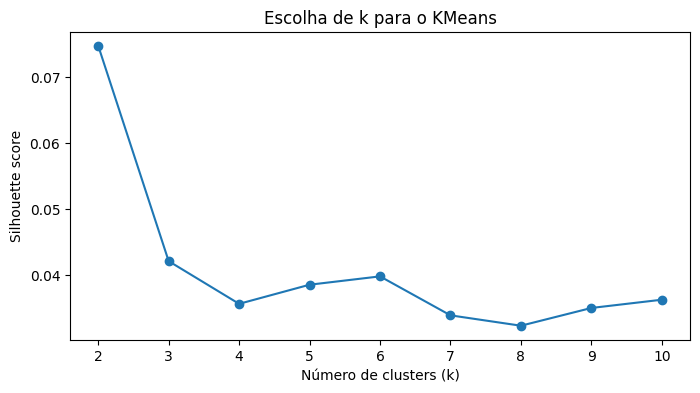

In [91]:
max_k_ajustado = min(MAX_K, len(df_textos) - 1)
if max_k_ajustado < MIN_K:
    raise ValueError("Não há textos suficientes para clusterização.")

resultados_silhouette = []
for k in range(MIN_K, max_k_ajustado + 1):
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    rotulos_tmp = kmeans_tmp.fit_predict(features_combinadas)
    score = silhouette_score(features_combinadas, rotulos_tmp)
    resultados_silhouette.append({"k": k, "silhouette": score})

df_silhouette = pd.DataFrame(resultados_silhouette)
display(df_silhouette)

melhor_k = int(df_silhouette.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Melhor k pelo silhouette score (KMeans):", melhor_k)

plt.figure(figsize=(8, 4))
plt.plot(df_silhouette["k"], df_silhouette["silhouette"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Escolha de k para o KMeans")
plt.show()


In [92]:
# Clusterização final com KMeans, usando o melhor k encontrado.
kmeans_final = KMeans(n_clusters=melhor_k, random_state=RANDOM_STATE, n_init="auto")
df_textos["cluster"] = kmeans_final.fit_predict(features_combinadas)

print("Quantidade de textos por cluster (KMeans):")
display(df_textos["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="quantidade"))

# Comparação com DBSCAN, que não exige definir k e pode marcar ruído (-1).
dbscan = DBSCAN(eps=3.0, min_samples=3)
rotulos_dbscan = dbscan.fit_predict(features_combinadas)
n_clusters_dbscan = len(set(rotulos_dbscan)) - (1 if -1 in rotulos_dbscan else 0)
n_ruido_dbscan = int((rotulos_dbscan == -1).sum())
print(f"\nDBSCAN: {n_clusters_dbscan} clusters encontrados, {n_ruido_dbscan} pontos marcados como ruído.")

# HDBSCAN, quando disponível, costuma lidar melhor com clusters de densidade variável.
if HDBSCAN_DISPONIVEL:
    clusterer_hdbscan = hdbscan.HDBSCAN(min_cluster_size=max(3, len(df_textos) // 30))
    rotulos_hdbscan = clusterer_hdbscan.fit_predict(features_combinadas)
    n_clusters_hdbscan = len(set(rotulos_hdbscan)) - (1 if -1 in rotulos_hdbscan else 0)
    n_ruido_hdbscan = int((rotulos_hdbscan == -1).sum())
    df_textos["cluster_hdbscan"] = rotulos_hdbscan
    print(f"HDBSCAN: {n_clusters_hdbscan} clusters encontrados, {n_ruido_hdbscan} pontos marcados como ruído.")
else:
    print("HDBSCAN não está instalado neste ambiente - comparação limitada a KMeans e DBSCAN.")

df_textos["cluster_dbscan"] = rotulos_dbscan


Quantidade de textos por cluster (KMeans):


,cluster,quantidade
0,0,500
1,1,300



DBSCAN: 7 clusters encontrados, 775 pontos marcados como ruído.
HDBSCAN: 0 clusters encontrados, 800 pontos marcados como ruído.


> **Nota metodológica:** o cluster "principal" usado no restante da interpretação é o
> do **KMeans**, por produzir grupos de tamanho mais equilibrado e não deixar pontos de
> fora (ruído). DBSCAN/HDBSCAN são mantidos como colunas auxiliares (`cluster_dbscan`,
> `cluster_hdbscan`) para comparação: se muitos pontos calharem de cair como ruído nesses
> algoritmos, isso é um indício de que a base tem poucos grupos bem definidos ou de que os
> parâmetros de densidade precisam ser ajustados.

### 2.10.1. Termos representativos por cluster (TF-IDF com stopwords do domínio)

Usamos a mesma matriz TF-IDF filtrada pelas stopwords do domínio (seção 2.3) para
identificar os termos mais característicos de cada cluster.

In [93]:
vectorizer_cluster = TfidfVectorizer(
    max_features=5000,
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 2),
    min_df=1,
    lowercase=True,
    strip_accents="unicode",
)

tfidf_cluster = vectorizer_cluster.fit_transform(df_textos["texto_limpo"])
termos_cluster = np.array(vectorizer_cluster.get_feature_names_out())

termos_por_cluster = {}
for cluster_id in sorted(df_textos["cluster"].unique()):
    indices = df_textos.index[df_textos["cluster"] == cluster_id].tolist()
    media_tfidf = np.asarray(tfidf_cluster[indices].mean(axis=0)).ravel()
    top_indices = media_tfidf.argsort()[::-1][:15]
    termos_por_cluster[cluster_id] = list(termos_cluster[top_indices])

for cluster_id, termos in termos_por_cluster.items():
    print(f"Cluster {cluster_id}: {', '.join(termos[:10])}")


Cluster 0: producao, ao, controle, partir, aplicacao, monitoramento, visa, solucao, materiais, sera
Cluster 1: solucao, software, plataforma, controle, inteligente, aplicacao, prototipo, iot, hardware, automacao


### 2.11. Visualização com PCA e t-SNE

* **PCA** projeta as features combinadas em 2 dimensões preservando o máximo possível
  da variância **global** dos dados — bom para enxergar a separação geral entre os
  clusters.
* **t-SNE** preserva melhor as relações **locais** (quais textos são parecidos com
  quais), revelando subgrupos e zonas de transição dentro dos clusters. Não deve ser
  interpretado como uma medida de distância absoluta e confiável entre pontos distantes,
  mas sim como um apoio visual para investigar a estrutura interna dos clusters.

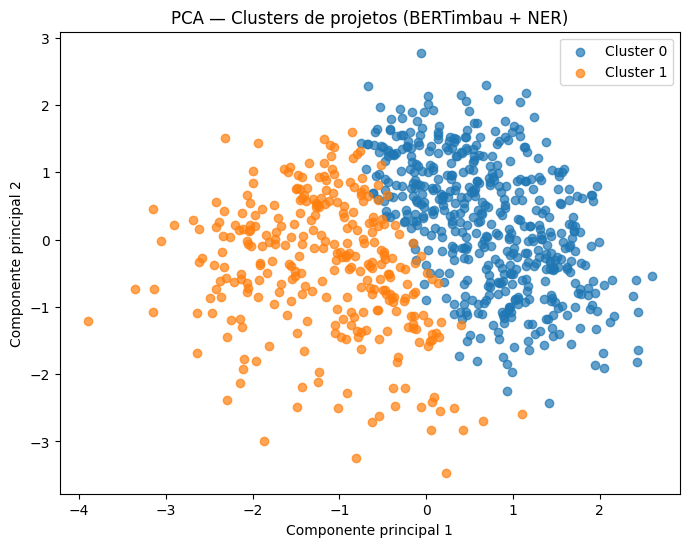

In [94]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pontos_pca = pca.fit_transform(features_combinadas)

df_plot_pca = pd.DataFrame({
    "x": pontos_pca[:, 0],
    "y": pontos_pca[:, 1],
    "cluster": df_textos["cluster"].astype(str),
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(df_plot_pca["cluster"].unique()):
    subset = df_plot_pca[df_plot_pca["cluster"] == cluster_id]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("PCA — Clusters de projetos (BERTimbau + NER)")
plt.legend()
plt.show()


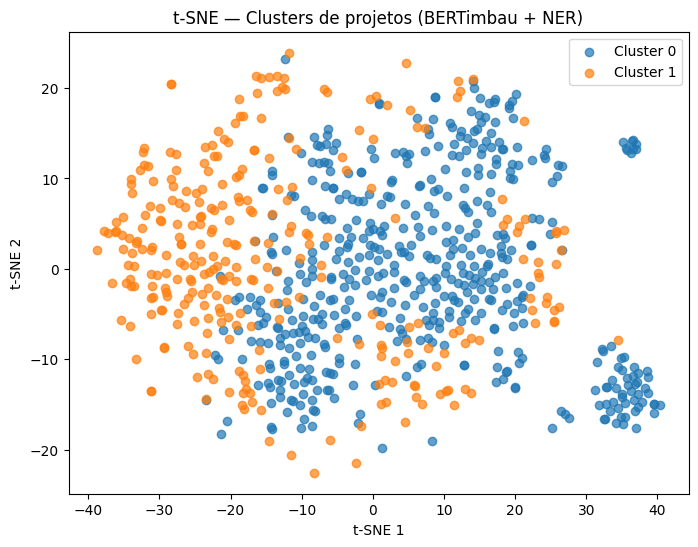

In [95]:
n_amostras = features_combinadas.shape[0]
perplexity = min(30, max(5, (n_amostras - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
pontos_tsne = tsne.fit_transform(features_combinadas)

df_plot_tsne = pd.DataFrame({
    "x": pontos_tsne[:, 0],
    "y": pontos_tsne[:, 1],
    "cluster": df_textos["cluster"].astype(str),
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(df_plot_tsne["cluster"].unique()):
    subset = df_plot_tsne[df_plot_tsne["cluster"] == cluster_id]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE — Clusters de projetos (BERTimbau + NER)")
plt.legend()
plt.show()


**Como ler os dois gráficos juntos:** o PCA mostra se existe uma separação global
razoável entre os clusters encontrados pelo KMeans; o t-SNE, por sua vez, revela se essa
separação é homogênea ou se há subgrupos, zonas de mistura e possíveis temas
intermediários dentro de cada cluster. Isso é esperado em textos de projetos de C,T&I,
já que dois projetos podem se parecer por área, por tecnologia, por material ou por
aplicação — dimensões que nem sempre coincidem.

### 2.12. Interpretação final dos resultados

In [96]:
def interpretar_cluster(cluster_id: int) -> str:
    """Gera uma frase-resumo interpretando o cluster a partir dos termos TF-IDF
    e das entidades de área/tecnologia mais frequentes nesse grupo.
    """
    subset = df_textos[df_textos["cluster"] == cluster_id]

    termos_top = termos_por_cluster.get(cluster_id, [])[:5]

    areas = subset["area_sugerida"].replace("", np.nan).dropna()
    area_dominante = areas.value_counts().idxmax() if not areas.empty else "não identificada claramente"

    tecnologias_flat = [
        tec.strip()
        for lista in subset["tecnologias_identificadas"]
        for tec in lista.split(";") if tec.strip()
    ]
    tecnologia_dominante = Counter(tecnologias_flat).most_common(1)[0][0] if tecnologias_flat else "não identificada claramente"

    return (
        f"Cluster {cluster_id} reúne {len(subset)} projetos. "
        f"A área predominante sugerida é '{area_dominante}', com forte presença da tecnologia "
        f"'{tecnologia_dominante}'. Os termos mais característicos (TF-IDF) são: "
        f"{', '.join(termos_top) if termos_top else 'poucos termos distintivos encontrados'}."
    )


linhas_resumo_cluster = []
for cluster_id in sorted(df_textos["cluster"].unique()):
    subset = df_textos[df_textos["cluster"] == cluster_id]
    interpretacao = interpretar_cluster(cluster_id)

    entidades_cluster = (
        df_entidades[df_entidades["id_texto"].isin(subset["id_texto"])]
        if len(df_entidades) > 0 else pd.DataFrame(columns=["entidade", "tipo_entidade"])
    )
    principais_entidades = (
        entidades_cluster["entidade"].str.lower().value_counts().head(10).index.tolist()
        if not entidades_cluster.empty else []
    )

    areas_cluster = subset["area_sugerida"].replace("", np.nan).dropna()
    area_predominante = areas_cluster.value_counts().idxmax() if not areas_cluster.empty else ""

    linhas_resumo_cluster.append({
        "cluster": cluster_id,
        "quantidade_textos": len(subset),
        "principais_termos_tfidf": ", ".join(termos_por_cluster.get(cluster_id, [])[:10]),
        "principais_entidades": ", ".join(principais_entidades),
        "area_predominante": area_predominante,
        "interpretacao": interpretacao,
        "exemplos_textos": " || ".join(subset["texto_original"].head(3).str.slice(0, 200).tolist()),
    })

df_resumo_clusters = pd.DataFrame(linhas_resumo_cluster)
display(df_resumo_clusters)


,cluster,quantidade_textos,principais_termos_tfidf,principais_entidades,area_predominante,interpretacao,exemplos_textos
0,0,500,"producao, ao, controle, partir, aplicacao, mon...","materiais, sistema de, plataforma, monitoramen...",materiais,Cluster 0 reúne 500 projetos. A área predomina...,Recuperação de Informação Inteligente e Aprend...
1,1,300,"solucao, software, plataforma, controle, intel...","software, plataforma, sistema de, protótipo, m...",software,Cluster 1 reúne 300 projetos. A área predomina...,Veículo Batedor Autônomo. Desenvolvimento de t...


In [97]:
# Tabela final consolidada, texto a texto.
df_resultado_final = df_textos.copy()
df_resultado_final["principais_termos_tfidf_do_cluster"] = df_resultado_final["cluster"].map(
    lambda c: ", ".join(termos_por_cluster.get(c, [])[:10])
)
df_resultado_final["interpretacao_cluster"] = df_resultado_final["cluster"].map(interpretar_cluster)
df_resultado_final["resumo_contexto"] = (
    df_resultado_final["area_sugerida"].replace("", "área não identificada")
    + " | tecnologias: "
    + df_resultado_final["tecnologias_identificadas"].replace("", "não identificadas")
)

colunas_finais = [
    "id_texto", "texto_original", "texto_limpo", "entidades_identificadas",
    "area_sugerida", "tecnologias_identificadas", "cluster",
    "principais_termos_tfidf_do_cluster", "interpretacao_cluster", "resumo_contexto",
]

df_resultado_final = df_resultado_final[colunas_finais]

print("Tabela final consolidada (amostra):")
display(df_resultado_final.head(10))


Tabela final consolidada (amostra):


,id_texto,texto_original,texto_limpo,entidades_identificadas,area_sugerida,tecnologias_identificadas,cluster,principais_termos_tfidf_do_cluster,interpretacao_cluster,resumo_contexto
0,0,Recuperação de Informação Inteligente e Aprend...,Recuperação de Informação Inteligente e Aprend...,Máquina (PRODUTO_SOLUCAO),,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
1,1,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,apoio (AREA),apoio,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,apoio | tecnologias: não identificadas
2,2,Veículo Batedor Autônomo. Desenvolvimento de t...,Veículo Batedor Autônomo. Desenvolvimento de t...,sensores (TECNOLOGIA),,sensores,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,área não identificada | tecnologias: sensores
3,3,Desenvolvimento e avaliação operacional de um...,Desenvolvimento e avaliação operacional de um ...,sistema de (PRODUTO_SOLUCAO); compósito (MATER...,,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
4,4,Seleção de um isolado de Cordyceps (Isaria) sp...,Seleção de um isolado de Cordyceps (Isaria) sp...,,,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
5,5,Viabilidade de aproveitamento de rejeitos de m...,Viabilidade de aproveitamento de rejeitos de m...,agricultura (AREA); produto (PRODUTO_SOLUCAO),agricultura,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,agricultura | tecnologias: não identificadas
6,6,AGUARDANDO AUTORIZAÇÃO CLIENTE - Subsistema d...,AGUARDANDO AUTORIZAÇÃO CLIENTE - Subsistema do...,Subsistema do (PRODUTO_SOLUCAO); modular (MATE...,,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
7,7,Desenvolvimento de tecnologias fotônicas inova...,Desenvolvimento de tecnologias fotônicas inova...,,,,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,área não identificada | tecnologias: não ident...
8,8,Desenvolvimento de componentes em material com...,Desenvolvimento de componentes em material com...,compósito (MATERIAL_RECURSO); compósito (MATER...,materiais,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,materiais | tecnologias: não identificadas
9,9,EMBRAPII CICS - Desenvolvimento de aços micro...,EMBRAPII CICS - Desenvolvimento de aços micro...,corrosão (MATERIAL_RECURSO),,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...


### 2.13. Exportação dos resultados

In [98]:
# training_data_para_curadoria.csv já foi exportado na seção 2.5.
# entidades_extraidas_ner.csv já foi exportado na seção 2.7.

caminho_resultado_final = "resultado_ner_bert_clusters.csv"
caminho_resumo_clusters = "resumo_interpretado_clusters.csv"

df_resultado_final.to_csv(caminho_resultado_final, index=False, encoding="latin-1")
df_resumo_clusters.to_csv(caminho_resumo_clusters, index=False, encoding="latin-1")

print("Arquivos exportados:")
print("- training_data_para_curadoria.csv")
print("- entidades_extraidas_ner.csv")
print(f"- {caminho_resultado_final}")
print(f"- {caminho_resumo_clusters}")

print("\nTabela final consolidada:")
display(df_resultado_final)

print("\nResumo interpretado por cluster:")
display(df_resumo_clusters)


Arquivos exportados:
- training_data_para_curadoria.csv
- entidades_extraidas_ner.csv
- resultado_ner_bert_clusters.csv
- resumo_interpretado_clusters.csv

Tabela final consolidada:


,id_texto,texto_original,texto_limpo,entidades_identificadas,area_sugerida,tecnologias_identificadas,cluster,principais_termos_tfidf_do_cluster,interpretacao_cluster,resumo_contexto
0,0,Recuperação de Informação Inteligente e Aprend...,Recuperação de Informação Inteligente e Aprend...,Máquina (PRODUTO_SOLUCAO),,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
1,1,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,DESENVOLVIMENTO E IMPLANTAÇÃO DE GÊMEO DIGITAL...,apoio (AREA),apoio,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,apoio | tecnologias: não identificadas
2,2,Veículo Batedor Autônomo. Desenvolvimento de t...,Veículo Batedor Autônomo. Desenvolvimento de t...,sensores (TECNOLOGIA),,sensores,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,área não identificada | tecnologias: sensores
3,3,Desenvolvimento e avaliação operacional de um...,Desenvolvimento e avaliação operacional de um ...,sistema de (PRODUTO_SOLUCAO); compósito (MATER...,,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
4,4,Seleção de um isolado de Cordyceps (Isaria) sp...,Seleção de um isolado de Cordyceps (Isaria) sp...,,,,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: não ident...
...,...,...,...,...,...,...,...,...,...,...
795,795,MSD. Sistema de automação dos processos de con...,MSD. Sistema de automação dos processos de con...,Sistema de (PRODUTO_SOLUCAO); automação (AREA),automação,,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,automação | tecnologias: não identificadas
796,796,Plataforma IoT para equipamento de energia. So...,Plataforma IoT para equipamento de energia. So...,Plataforma (PRODUTO_SOLUCAO); equipamento (PRO...,energia,,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,energia | tecnologias: não identificadas
797,797,Plataforma de AudioBooks com IA. Este projeto ...,Plataforma de AudioBooks com IA. Este projeto ...,Plataforma (PRODUTO_SOLUCAO); plataforma (PROD...,,inteligência artificial,0,"producao, ao, controle, partir, aplicacao, mon...",Cluster 0 reúne 500 projetos. A área predomina...,área não identificada | tecnologias: inteligên...
798,798,OLTest. Plataforma de testes automáticos para ...,OLTest. Plataforma de testes automáticos para ...,Plataforma (PRODUTO_SOLUCAO),,,1,"solucao, software, plataforma, controle, intel...",Cluster 1 reúne 300 projetos. A área predomina...,área não identificada | tecnologias: não ident...



Resumo interpretado por cluster:


,cluster,quantidade_textos,principais_termos_tfidf,principais_entidades,area_predominante,interpretacao,exemplos_textos
0,0,500,"producao, ao, controle, partir, aplicacao, mon...","materiais, sistema de, plataforma, monitoramen...",materiais,Cluster 0 reúne 500 projetos. A área predomina...,Recuperação de Informação Inteligente e Aprend...
1,1,300,"solucao, software, plataforma, controle, intel...","software, plataforma, sistema de, protótipo, m...",software,Cluster 1 reúne 300 projetos. A área predomina...,Veículo Batedor Autônomo. Desenvolvimento de t...


### 2.14. Conclusão

Este pipeline respondeu, para o dataset DL-2024 (2014):

* **Quais são as áreas dos projetos** — via a coluna `area_sugerida`, derivada da
  entidade `AREA` mais frequente extraída pelo NER em cada texto;
* **Quais tecnologias aparecem com mais frequência** — via a coluna
  `tecnologias_identificadas` e o relatório de contagem de entidades `TECNOLOGIA`;
* **Quais projetos pertencem ao mesmo contexto** — via a coluna `cluster`, obtida
  agrupando embeddings do BERTimbau combinados com as features estruturadas do NER;
* **Quais clusters existem, e o que os explica** — via `resumo_interpretado_clusters.csv`,
  que traz termos TF-IDF, entidades e área predominante por cluster;
* **Quais ruídos foram removidos** — via a lista `STOPWORDS_DOMINIO`, construída a
  partir da análise TF-IDF antes/depois (seção 2.3);
* **Como PCA e t-SNE ajudam a visualizar os agrupamentos** — PCA mostra a separação
  global entre clusters; t-SNE revela subgrupos e zonas de transição internas a cada
  cluster.

Em resumo: o **BERTimbau** captura o contexto semântico dos textos — a "sensação geral"
de do que trata cada projeto —, enquanto o **NER** extrai elementos interpretáveis e
explícitos (área, tecnologia, produto, material, objetivo). A combinação dos dois permite
separar melhor os projetos por contexto real e gerar clusters mais explicáveis do que
qualquer uma das duas abordagens isoladamente.

> Como o treinamento do NER depende da qualidade da curadoria de `TRAINING_DATA`
> (weak supervision automática ou revisão manual via `training_data_revisado.csv`), os
> resultados devem ser lidos como um ponto de partida experimental, a ser refinado com
> mais dados anotados manualmente em trabalhos futuros.
